# RQ1_new — analysis

Reads from `clean_data/<model>_<kind>_joined.csv`, built by the join step in `silvia_analysis.ipynb` (rerun that after collecting new data to refresh these files).

**Methodology note (2026-08-10):** earlier versions of this notebook read from `clean_data/<model>.csv`, a curated pool built by `build_clean_dataset.py` that only included rounds individually audited to rule out a specific bug (a co-runner reported `Ready` but not actually consuming CPU, silently zeroing out the contention effect a cell was supposed to measure). That audit can only be done retroactively by comparing a round's numbers against its siblings — there's no way to go back and directly confirm the co-runner *was* running for a round collected before the harness added its own liveness check. Given that, the working decision going forward is to pool everything collected for a model/kind and assume the co-runner was live throughout, rather than exclude rounds on a signal that's this indirect. `build_clean_dataset.py`/`ROUND_STATUS` still exist and still work if the curated approach is wanted again later — this notebook just doesn't read from it anymore.

Every model/kind combination found in `results/` is included (via `al.all_rounds`, a plain glob — no per-round exclusion). `model2` still has no `_joined.csv` files since a join was never built for it. Every section below is split by `(model, kind)`, and Section C makes the matmul-vs-ptrchase comparison explicit. Section A.0 is a data-quality pass (row counts, NaN, physically-impossible values) — it catches corrupted rows but NOT the liveness issue described above, which produces well-formed rows with an understated effect, invisible to this kind of check.

In [1]:
import sys

sys.path.append("/home/silvia/Documents/GraduationProject/research-questions/RQ1_new/analysis")

import analysis_lib as al
import pandas as pd
pd.set_option("display.width", 140)

MODELS = ["model1", "model3", "model3-w2", "model3-w3", "model3-w4"]  # model2 excluded: no joined files built
KINDS = ["matmul", "ptrchase"]

# data[(model, kind)] -- single-workload frame, used by every per-workload
# section below so R/C distributions of two different workloads never get
# pooled together by accident (they use different reservation sizes/K
# calibration and aren't comparable as one blended sample).
data = {(m, k): al.load_model(m, kind=k) for m in MODELS for k in KINDS}

# data_both[model] -- both kinds together (kind column intact), used only by
# Section C's direct matmul-vs-ptrchase comparison.
data_both = {m: al.load_model_both(m) for m in MODELS}

## Section A — pooled dataset (all U together)

### A.0 Data quality checks
Straight from each included round's raw jobs.csv (not the pooled file, same reasoning as A.4/A.5): per cell, flags row count != 5000, duplicate `job_index`, NaN in R/C/deadline_miss, C<=0, or R < C (physically impossible -- wall response can't be shorter than the execution time it contains). This only checks cells that exist; a cell missing entirely (e.g. model3-w2's round4 gap, model3-w4's admission-ceiling gaps) won't show up here as "bad" -- it just won't appear in the cell count. Cross-check the cell counts below against 20 (both scales) x (rounds included) if completeness itself is in question.

In [2]:
for m in MODELS:
    for k in KINDS:
        t = al.data_quality_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) === {t['bad_cells'].sum()} bad cell(s) / {t['cells'].sum()} checked")
        bad = t[t["bad_cells"] > 0]
        if not bad.empty:
            display(bad)

=== model1 (matmul) === 1 bad cell(s) / 79 checked


,round,cells,bad_cells,issues
1,model1_round2,19,1,soft/U0.9: R<C in 3 job(s)


=== model1 (ptrchase) === 0 bad cell(s) / 79 checked


=== model3 (matmul) === 0 bad cell(s) / 78 checked


=== model3 (ptrchase) === 0 bad cell(s) / 80 checked


...

=== model3-w2 (ptrchase) === 0 bad cell(s) / 80 checked


=== model3-w3 (matmul) === 0 bad cell(s) / 80 checked


=== model3-w3 (ptrchase) === 0 bad cell(s) / 80 checked


=== model3-w4 (matmul) === 0 bad cell(s) / 72 checked


=== model3-w4 (ptrchase) === 0 bad cell(s) / 80 checked


### A.1 Basic descriptives

In [3]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.descriptives_table(df))

=== model1 (matmul) ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,"R (response, ms)",195000,39.403,19.978,6.856,42.533,67.344,68.379,72.684,652.541
1,soft,"C (execution, ms)",195000,39.327,19.918,6.849,42.499,67.319,68.327,71.419,103.283
2,tight,"R (response, ms)",200000,4.020,2.054,0.702,4.298,6.865,6.930,10.029,35.576
3,tight,"C (execution, ms)",200000,4.001,2.039,0.694,4.263,6.848,6.914,7.003,10.948


=== model1 (ptrchase) ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,"R (response, ms)",200000,38.411,19.242,6.885,40.838,65.507,67.656,74.617,131.723
1,soft,"C (execution, ms)",200000,38.307,19.185,6.871,40.744,65.478,67.591,69.605,121.839
2,tight,"R (response, ms)",200000,3.854,2.055,0.678,4.150,6.526,6.711,10.727,264.694
3,tight,"C (execution, ms)",200000,3.818,1.934,0.658,4.119,6.504,6.675,6.982,11.512


=== model3 (matmul) ===


...

,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,"R (response, ms)",200000,37.385,18.450,7.013,37.634,63.904,65.546,66.824,161.347
1,soft,"C (execution, ms)",200000,37.270,18.503,6.928,37.295,63.875,65.517,66.783,155.566
2,tight,"R (response, ms)",200000,3.760,1.895,0.704,3.622,6.570,6.668,6.753,53.394
3,tight,"C (execution, ms)",200000,3.737,1.885,0.688,3.587,6.550,6.647,6.713,12.667


=== model3-w4 (matmul) ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,"R (response, ms)",200000,39.496,20.178,7.031,42.407,68.001,68.677,100.222,122.211
1,soft,"C (execution, ms)",200000,39.341,20.125,6.870,42.320,67.964,68.625,74.156,108.158
2,tight,"R (response, ms)",160000,3.827,2.143,0.710,3.656,6.867,7.119,10.741,38.007
3,tight,"C (execution, ms)",160000,3.777,2.098,0.694,3.628,6.829,7.030,8.505,12.158


=== model3-w4 (ptrchase) ===


,scale,metric,n,mean,std,min,p50,p95,p99,p999,max
0,soft,"R (response, ms)",200000,39.683,19.965,7.155,42.037,67.413,70.182,72.942,201.748
1,soft,"C (execution, ms)",200000,39.587,19.965,7.076,41.929,67.374,70.115,72.618,162.630
2,tight,"R (response, ms)",200000,3.979,2.034,0.722,4.217,6.978,7.185,7.568,26.541
3,tight,"C (execution, ms)",200000,3.952,2.028,0.706,4.175,6.956,7.157,7.481,12.888


### A.2 Distribution of R and C over U
Boxplots, not a single collapsed histogram — R and C aren't comparable across different U cells (different Q/period), so the shape needs to be shown *per U*, not pooled across it.

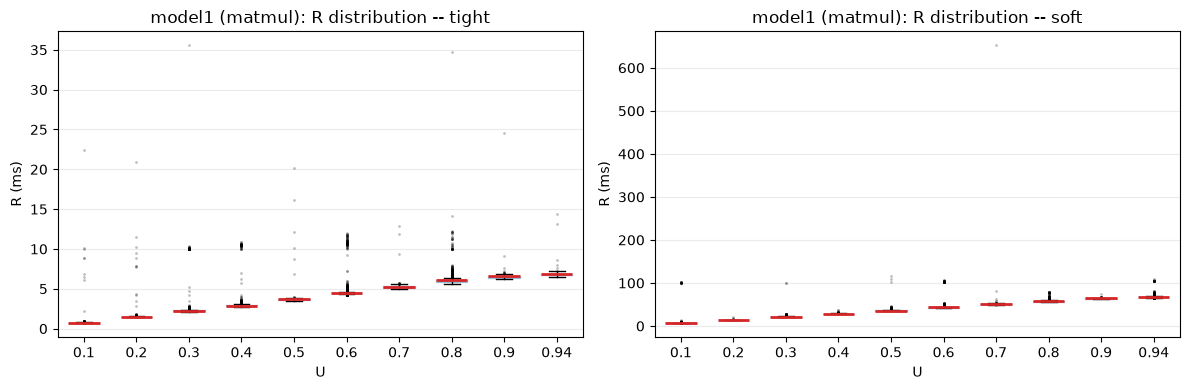

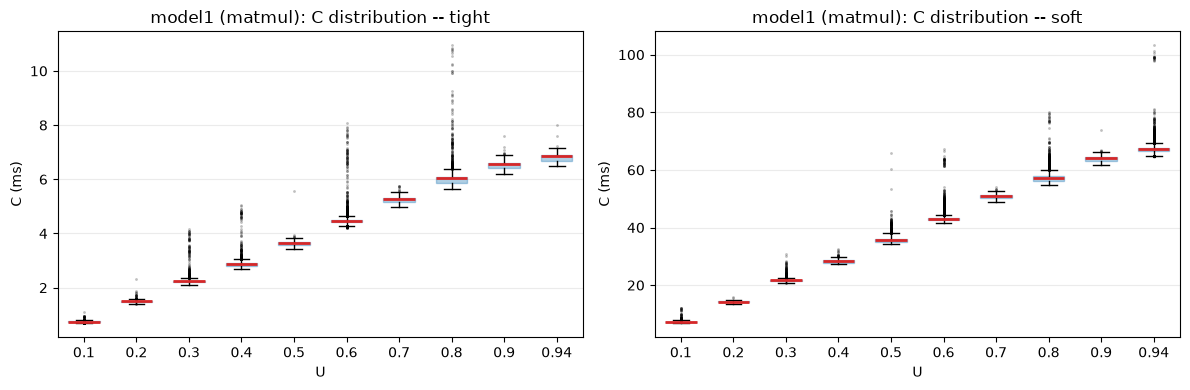

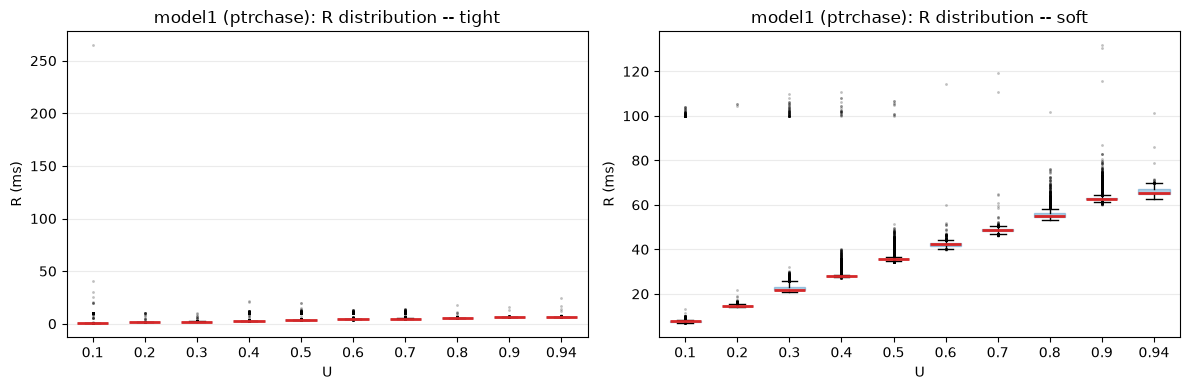

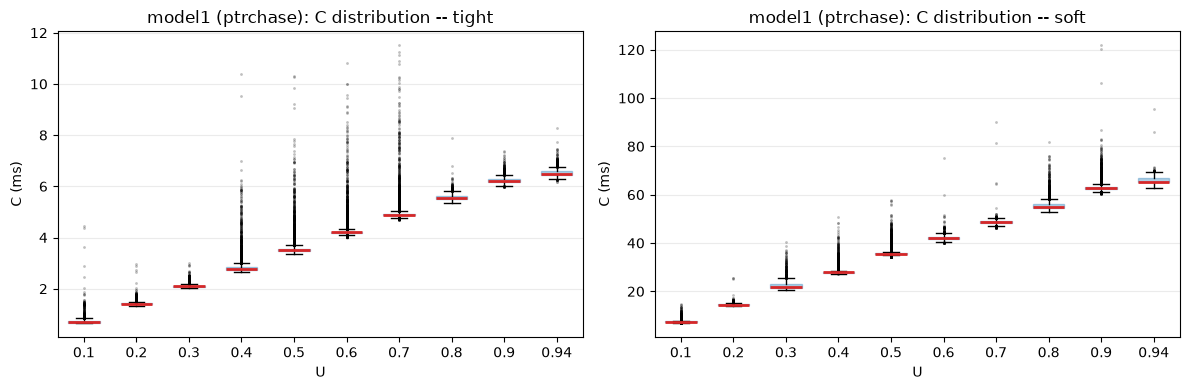

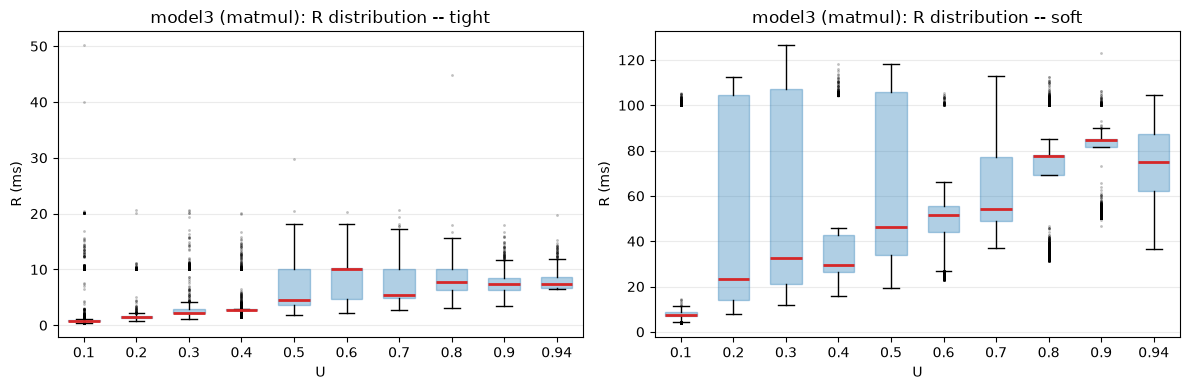

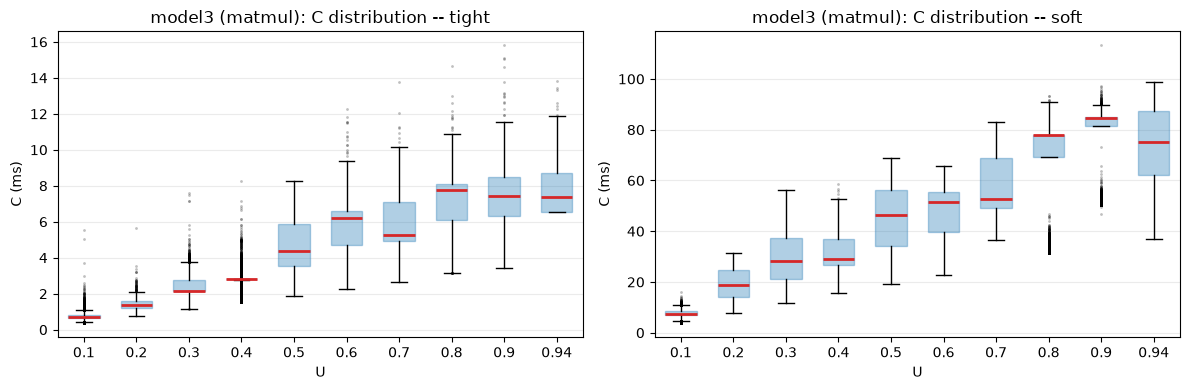

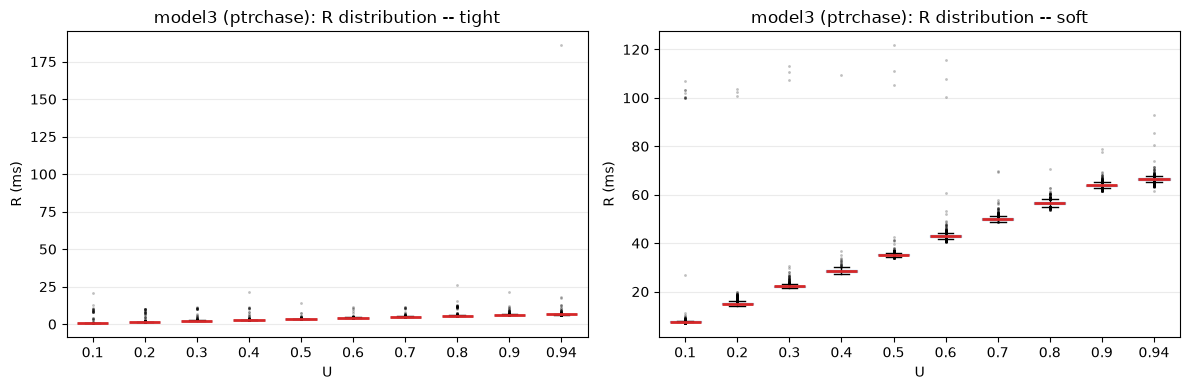

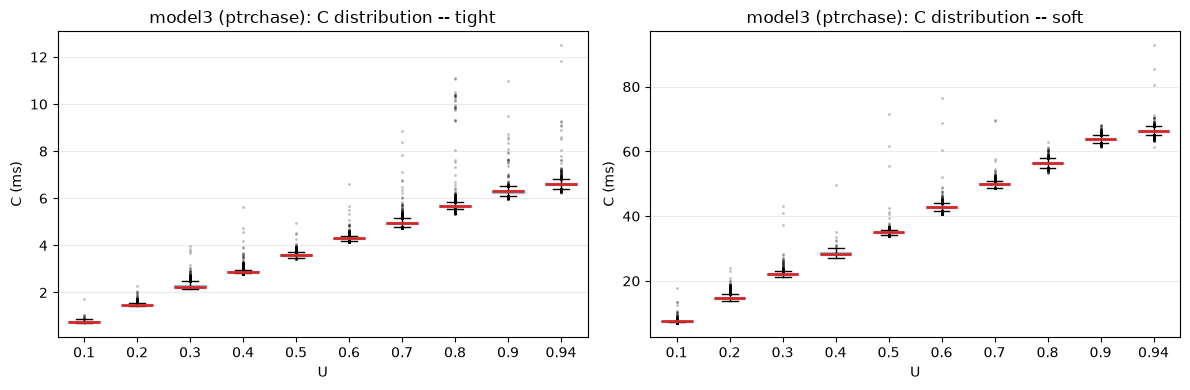

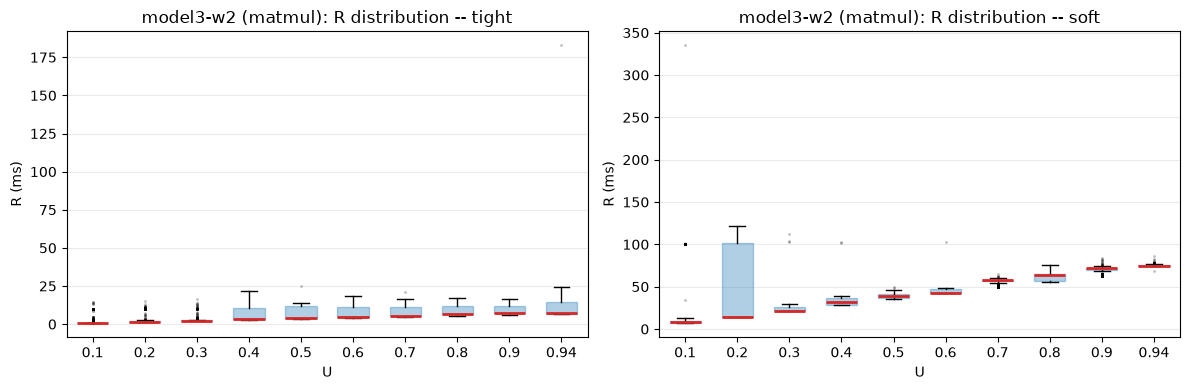

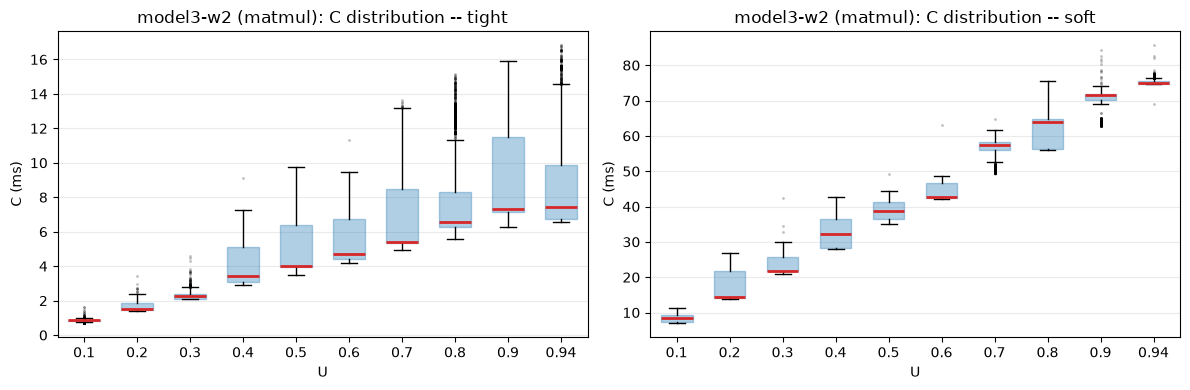

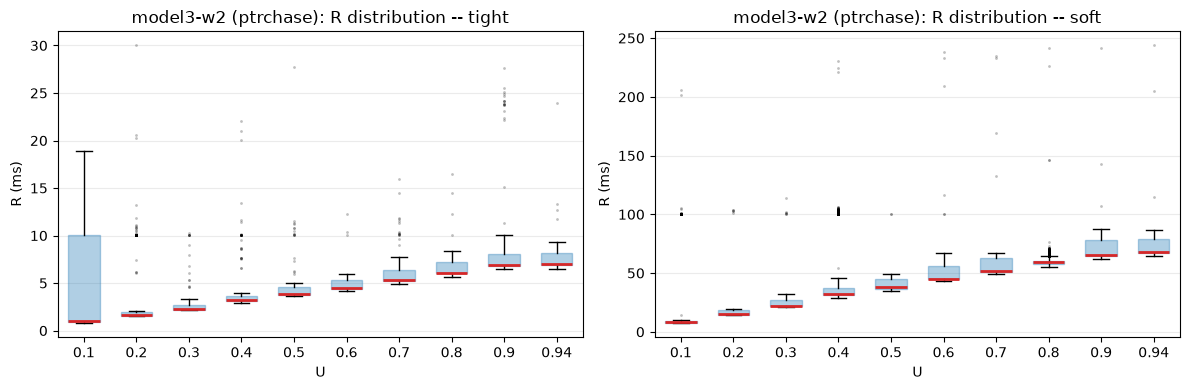

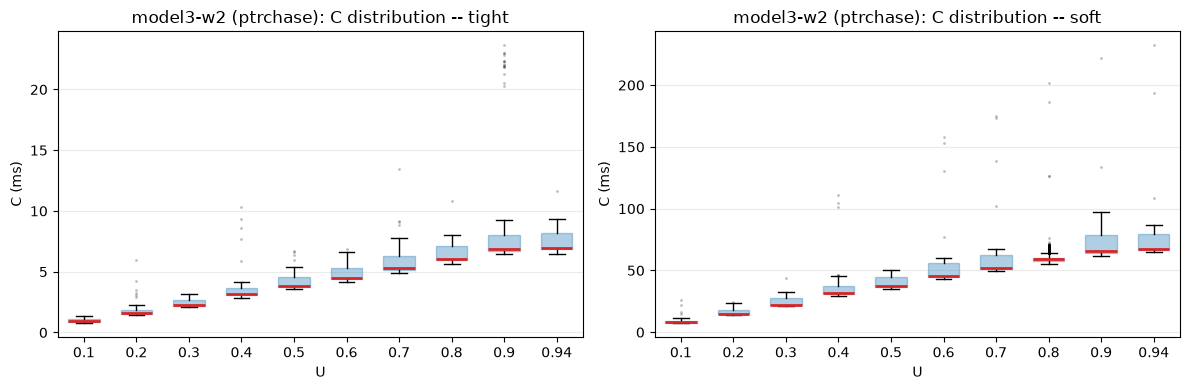

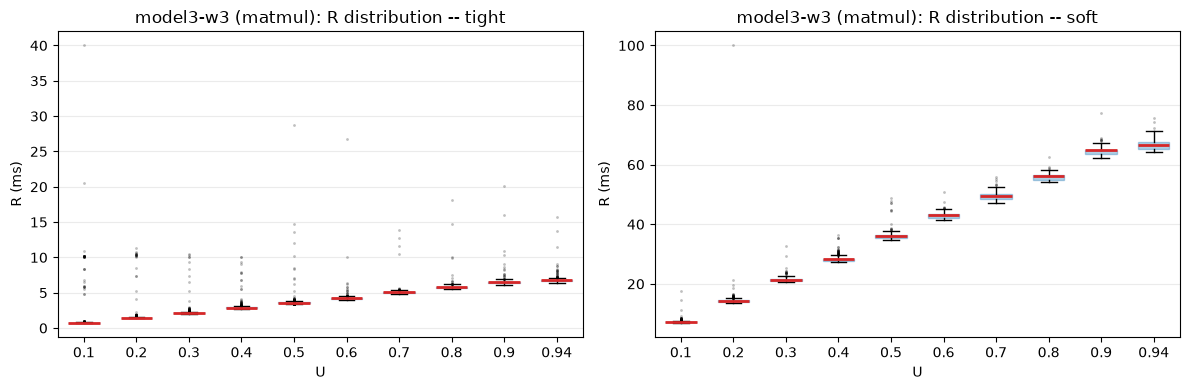

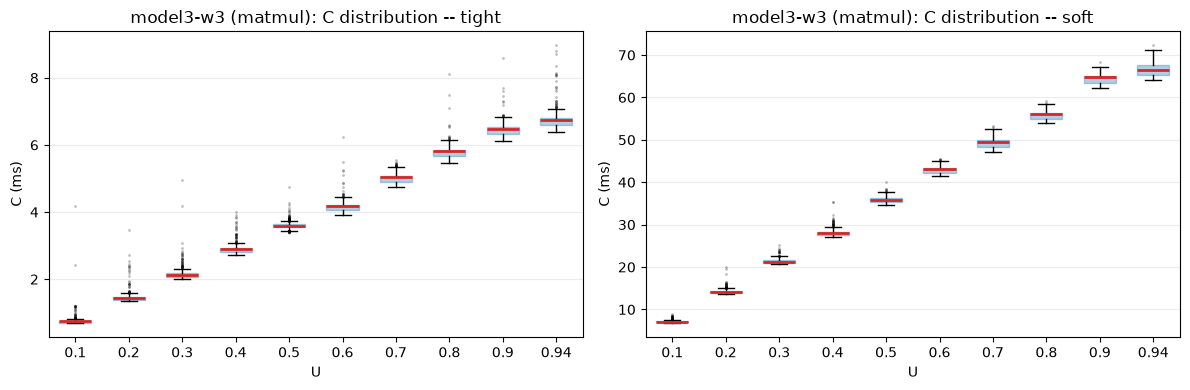

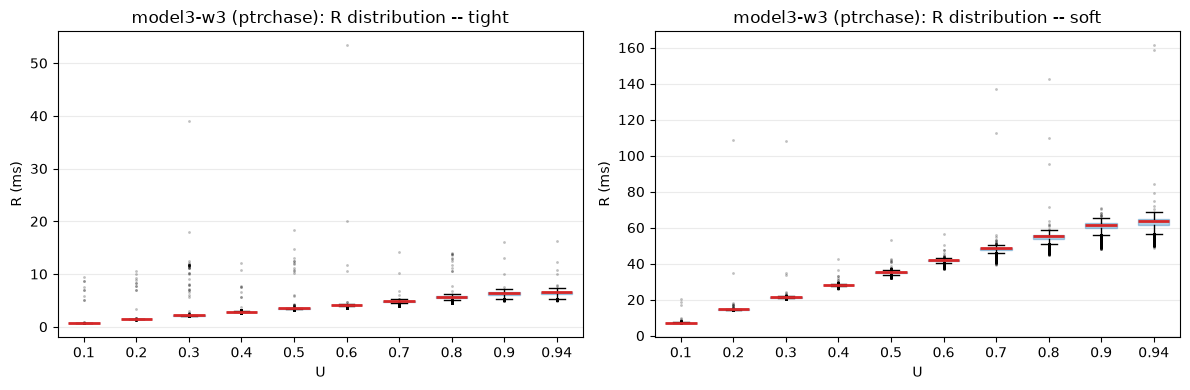

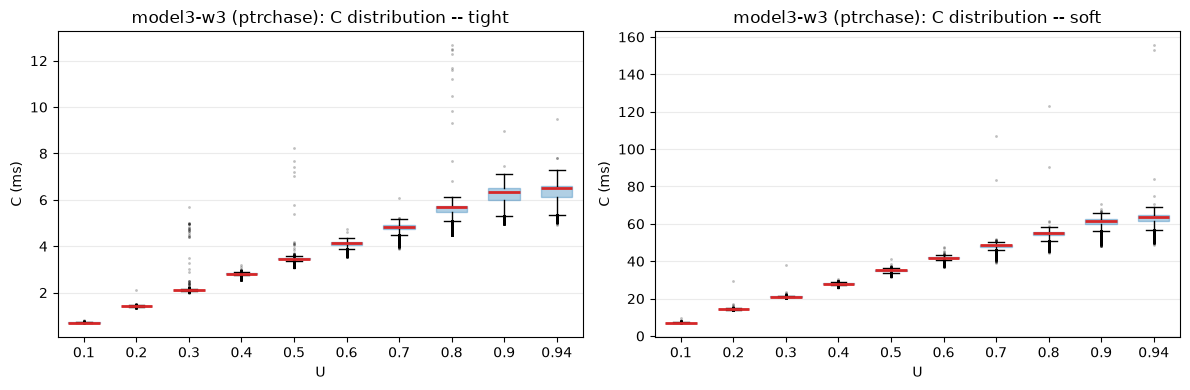

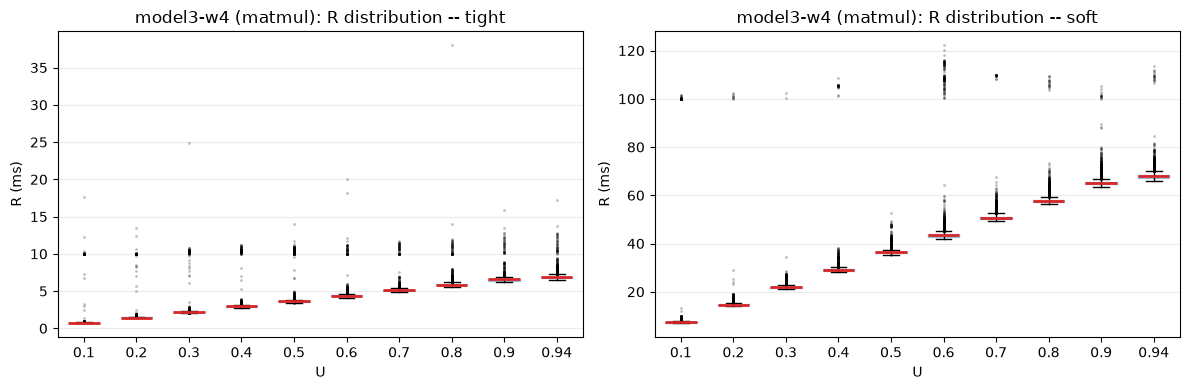

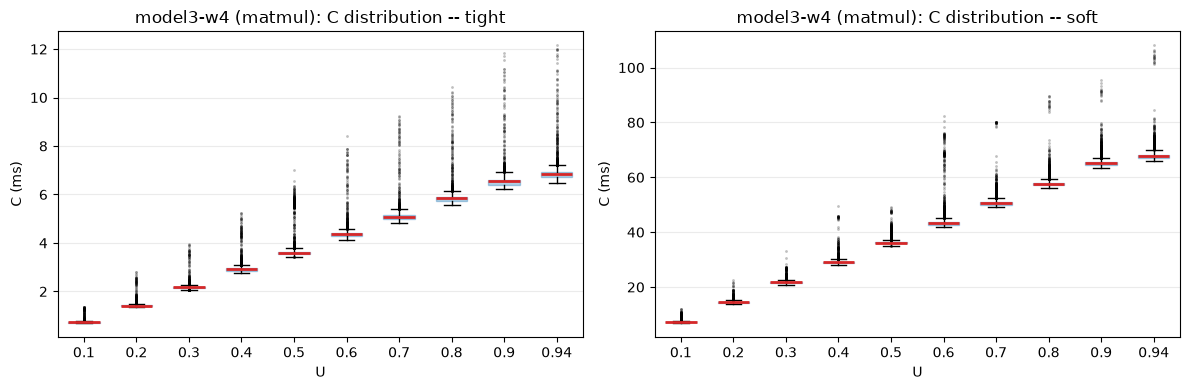

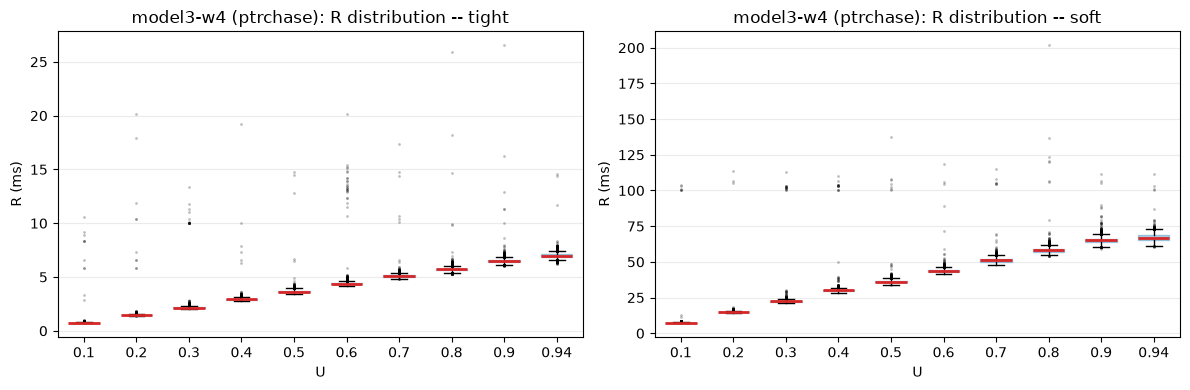

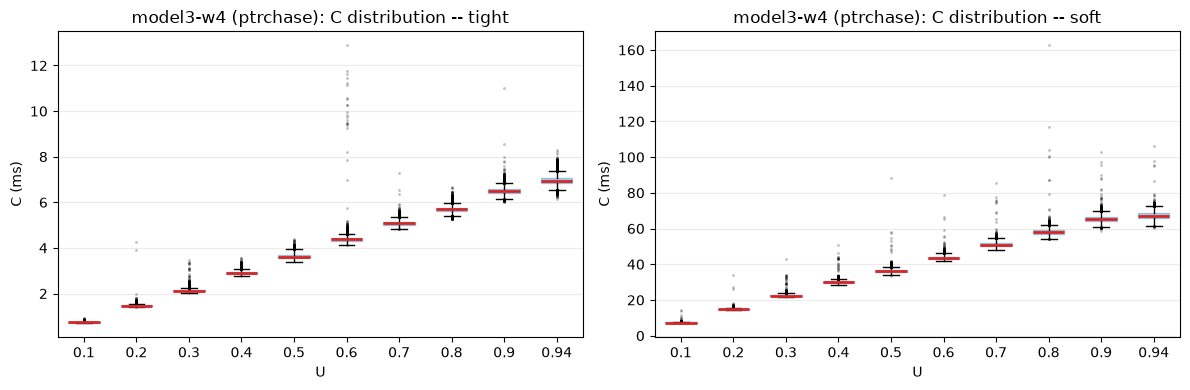

In [4]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        al.distribution_over_u(df, "R_wall_ms", "R (ms)", f"{m} ({k}): R distribution")
        al.distribution_over_u(df, "C_cputime_ms", "C (ms)", f"{m} ({k}): C distribution")

### A.3 Budget overrun (alpha > 1)
How often execution ALONE exceeds the reservation's own budget — independent of whether the job also missed its deadline.

In [5]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.budget_overrun_table(df))

=== model1 (matmul) ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0006,0.726,0.767,1.213
1,soft,0.20,20000,0.0000,0.710,0.727,0.802
2,soft,0.30,15000,0.0001,0.722,0.762,1.024
3,soft,0.40,20000,0.0000,0.708,0.721,0.811
4,soft,0.50,20000,0.0001,0.712,0.763,1.317
5,soft,0.60,20000,0.0017,0.718,0.783,1.120
6,soft,0.70,20000,0.0000,0.730,0.736,0.773
7,soft,0.80,20000,0.0000,0.716,0.762,1.000
8,soft,0.90,20000,0.0000,0.713,0.718,0.820
9,soft,0.94,20000,0.0008,0.716,0.754,1.099


=== model1 (ptrchase) ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0035,0.746,0.890,1.483
1,soft,0.20,20000,0.0001,0.725,0.769,1.280
2,soft,0.30,20000,0.0024,0.725,0.846,1.353
3,soft,0.40,20000,0.0009,0.697,0.806,1.273
4,soft,0.50,20000,0.0004,0.713,0.810,1.158
5,soft,0.60,20000,0.0000,0.702,0.729,1.252
6,soft,0.70,20000,0.0001,0.696,0.713,1.288
7,soft,0.80,20000,0.0000,0.688,0.766,1.022
8,soft,0.90,20000,0.0001,0.697,0.765,1.354
9,soft,0.94,20000,0.0000,0.696,0.726,1.014


=== model3 (matmul) ===


...

,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0000,0.709,0.728,0.937
1,soft,0.20,20000,0.0000,0.723,0.734,1.460
2,soft,0.30,20000,0.0000,0.704,0.715,1.270
3,soft,0.40,20000,0.0000,0.701,0.716,0.768
4,soft,0.50,20000,0.0000,0.702,0.720,0.827
5,soft,0.60,20000,0.0000,0.699,0.711,0.793
6,soft,0.70,20000,0.0001,0.692,0.707,1.532
7,soft,0.80,20000,0.0001,0.690,0.714,1.541
8,soft,0.90,20000,0.0000,0.685,0.702,0.784
9,soft,0.94,20000,0.0001,0.679,0.710,1.655


=== model3-w4 (matmul) ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0016,0.720,0.769,1.199
1,soft,0.20,20000,0.0004,0.725,0.752,1.127
2,soft,0.30,20000,0.0001,0.724,0.749,1.099
3,soft,0.40,20000,0.0010,0.726,0.773,1.236
4,soft,0.50,20000,0.0000,0.724,0.774,0.986
5,soft,0.60,20000,0.0051,0.723,0.810,1.373
6,soft,0.70,20000,0.0008,0.724,0.781,1.148
7,soft,0.80,20000,0.0008,0.722,0.777,1.122
8,soft,0.90,20000,0.0006,0.724,0.774,1.059
9,soft,0.94,20000,0.0008,0.723,0.774,1.151


=== model3-w4 (ptrchase) ===


,scale,U,n,overrun_rate,alpha_p50,alpha_p99,alpha_max
0,soft,0.10,20000,0.0003,0.733,0.792,1.449
1,soft,0.20,20000,0.0001,0.737,0.797,1.700
2,soft,0.30,20000,0.0006,0.745,0.803,1.438
3,soft,0.40,20000,0.0006,0.748,0.803,1.268
4,soft,0.50,20000,0.0004,0.721,0.781,1.761
5,soft,0.60,20000,0.0001,0.725,0.777,1.316
6,soft,0.70,20000,0.0003,0.728,0.780,1.219
7,soft,0.80,20000,0.0004,0.726,0.780,2.033
8,soft,0.90,20000,0.0001,0.727,0.777,1.140
9,soft,0.94,20000,0.0002,0.713,0.769,1.128


### A.4 Round-to-round stability (QA check, keep this)
Straight from the included rounds' own raw data, not the pooled file — this is the exact check that caught the coin-flip bug. A round whose numbers don't match its siblings at the same U is the tell; pooling alone hides it. Re-check this whenever a new round is added to `clean_data`.

In [6]:
for m in MODELS:
    for k in KINDS:
        t = al.round_stability_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) ===")
        display(t)

=== model1 (matmul) ===


model1_round1  model1_round2  model1_round3  model1_round4  C_p50[model1_round1]  C_p50[model1_round2]  C_p50[model1_round3]  \
scale U                                                                                                                                    
soft  0.10         0.0026         0.0000         0.0000         0.0000             7434.4300             7065.8655             7282.3540   
      0.20         0.0000         0.0000         0.0000         0.0000            14446.4250            13967.2060            14112.8245   
      0.30         0.0000            NaN         0.0000         0.0004            21684.3765                   NaN            21228.3180   
      0.40         0.0000         0.0000         0.0000         0.0000            28625.6135            27664.4960            28182.5740   
      0.50         0.0006         0.0000         0.0000         0.0000            36662.0490            34715.8340            35338.1050   
      0.60         0.0000         0.0034         0.0000         0.0034            43235.0700            42628.1895            42616.5520   
      0.70         0.0002         0.0000         0.0000         0.0000            51227.5170            49585.3780            51053.2375   
      0.80         0.0000         0.0000         0.0000         0.0000            58551.3980            55375.2120            57153.0870   
      0.90         0.0000         0.0000         0.0000         0.0000            64414.4070            62203.5910            64129.1850   
      0.94         0.0000         0.0000         0.0034         0.0000            67372.6380            65104.0550            68194.9515   
tight 0.10         0.0002         0.0000         0.0002         0.0002              755.4970              731.2620              744.5545   
      0.20         0.0000         0.0002         0.0004         0.0000             1509.9295             1461.7120             1498.6200   
      0.30         0.0000         0.0000         0.0124         0.0002             2258.6450             2186.7960             2261.4010   
      0.40         0.0074         0.0000         0.0000         0.0000             2921.0015             2793.4200             2865.3500   
      0.50         0.0000         0.0002         0.0002         0.0004             3676.2875             3560.8915             3654.6995   
      0.60         0.0000         0.0070         0.0000         0.0066             4460.2485             4419.5960             4432.9885   
      0.70         0.0000         0.0002         0.0000         0.0002             5309.0280             5126.7080             5249.0175   
      0.80         0.0002         0.0002         0.0002         0.0064             6057.7930             5858.9295             5998.6150   
      0.90         0.0000         0.0000         0.0002         0.0000             6592.2035             6365.7760             6530.9380   
      0.94         0.0002         0.0002         0.0000         0.0000             6882.8785             6649.7660             6842.8305   

            C_p50[model1_round4]  
scale U                           
soft  0.10             7225.1150  
      0.20            14299.5625  
      0.30            21910.3115  
      0.40            28487.3775  
      0.50            35753.3180  
      0.60            43592.0795  
      0.70            51219.0010  
      0.80            57320.1330  
      0.90            64243.1560  
      0.94            67252.5890  
tight 0.10              755.4135  
      0.20             1504.8390  
      0.30             2258.2480  
      0.40             2880.0490  
      0.50             3670.8695  
      0.60             4557.9270  
      0.70             5285.9535  
      0.80             6127.8980  
      0.90             6578.9570  
      0.94             6877.5095

=== model1 (ptrchase) ===


model1_ptrchase_round1  model1_ptrchase_round2  model1_ptrchase_round3  model1_ptrchase_round4  C_p50[model1_ptrchase_round1]  \
scale U                                                                                                                                     
soft  0.10                  0.0002                  0.0000                  0.0002                  0.0142                      7104.8195   
      0.20                  0.0004                  0.0000                  0.0000                  0.0002                     14349.6675   
      0.30                  0.0006                     NaN                  0.0000                  0.0088                     21397.3345   
      0.40                  0.0000                  0.0000                  0.0000                  0.0038                     27830.1000   
      0.50                  0.0000                  0.0000                  0.0000                  0.0018                     35797.5200   
      0.60                  0.0002                  0.0000                  0.0000                  0.0000                     41889.1105   
      0.70                  0.0004                  0.0000                  0.0000                  0.0000                     48876.8595   
      0.80                  0.0000                  0.0000                  0.0000                  0.0002                     54820.7450   
      0.90                  0.0004                  0.0000                  0.0002                  0.0000                     63398.9955   
      0.94                  0.0002                  0.0000                  0.0000                  0.0000                     65435.0370   
tight 0.10                  0.0140                  0.0000                  0.0010                  0.0140                       681.0675   
      0.20                  0.0000                  0.0002                  0.0002                  0.0008                      1415.8170   
      0.30                  0.0000                  0.0000                  0.0000                  0.0002                      2089.0685   
      0.40                  0.0012                  0.0002                  0.0000                  0.0256                      2749.7185   
      0.50                  0.0002                  0.0000                  0.0000                  0.0258                      3523.8390   
      0.60                  0.0002                  0.0000                  0.0002                  0.0194                      4183.7625   
      0.70                  0.0002                  0.0000                  0.0000                  0.0186                      4904.9225   
      0.80                  0.0002                  0.0002                  0.0002                  0.0000                      5681.0920   
      0.90                  0.0002                  0.0002                  0.0000                  0.0000                      6315.1310   
      0.94                  0.0002                  0.0002                  0.0002                  0.0002                      6631.4745   

            C_p50[model1_ptrchase_round2]  C_p50[model1_ptrchase_round3]  C_p50[model1_ptrchase_round4]  
scale U                                                                                                  
soft  0.10                      7451.5625                      7532.6890                      7474.2215  
      0.20                     14338.3550                     14592.2260                     14763.1590  
      0.30                            NaN                     21743.7260                     21752.3950  
      0.40                     27932.8825                     27695.9505                     28418.6680  
      0.50                     35619.0625                     35534.2575                     35537.4850  
      0.60                     42242.5050                     43030.2395                     41272.1335  
      0.70                     48584.8365                    

=== model3 (matmul) ===


...

model3-w3_phys_cfs_ptrchase_round1  model3-w3_phys_cfs_ptrchase_round2  model3-w3_phys_cfs_ptrchase_round3  \
scale U                                                                                                                  
soft  0.10                              0.0000                              0.0000                              0.0000   
      0.20                              0.0000                              0.0000                              0.0000   
      0.30                              0.0000                              0.0002                              0.0000   
      0.40                              0.0000                              0.0000                              0.0000   
      0.50                              0.0000                              0.0000                              0.0000   
      0.60                              0.0000                              0.0000                              0.0000   
      0.70                              0.0000                              0.0000                              0.0002   
      0.80                              0.0000                              0.0000                              0.0004   
      0.90                              0.0000                              0.0000                              0.0000   
      0.94                              0.0000                              0.0000                              0.0004   
tight 0.10                              0.0000                              0.0000                              0.0000   
      0.20                              0.0000                              0.0000                              0.0002   
      0.30                              0.0000                              0.0006                              0.0042   
      0.40                              0.0000                              0.0002                              0.0002   
      0.50                              0.0004                              0.0012                              0.0002   
      0.60                              0.0002                              0.0002                              0.0002   
      0.70                              0.0002                              0.0002                              0.0000   
      0.80                              0.0000                              0.0002                              0.0000   
      0.90                              0.0002                              0.0000                              0.0004   
      0.94                              0.0002                              0.0004                              0.0000   

            model3-w3_phys_cfs_ptrchase_round4  C_p50[model3-w3_phys_cfs_ptrchase_round1]  C_p50[model3-w3_phys_cfs_ptrchase_round2]  \
scale U                                                                                                                                
soft  0.10                              0.0000                                  7076.2835                                  7117.4050   
      0.20                              0.0002                                 14429.2450                                 14531.4580   
      0.30                              0.0000                                 21075.3210                                 21198.9355   
      0.40                              0.0000                                 27955.9700                                 28124.7315   
      0.50                              0.0000                                 34975.3980                                 35210.0765   
      0.60                              0.0000                                 41775.2535                                 42141.9025   
      0.70                              0.0002                                 48140.8720                                 48776.3295   
      0.80                              0.0000                                 55003.6195              

=== model3-w4 (matmul) ===


model3-w4_phys_res_round1  model3-w4_phys_res_round2  model3-w4_phys_res_round3  model3-w4_phys_res_round4  \
scale U                                                                                                                  
soft  0.10                     0.0000                     0.0064                     0.0000                     0.0000   
      0.20                     0.0000                     0.0014                     0.0000                     0.0002   
      0.30                     0.0000                     0.0004                     0.0000                     0.0000   
      0.40                     0.0000                     0.0040                     0.0002                     0.0000   
      0.50                     0.0000                     0.0000                     0.0000                     0.0000   
      0.60                     0.0000                     0.0204                     0.0000                     0.0000   
      0.70                     0.0000                     0.0034                     0.0000                     0.0000   
      0.80                     0.0000                     0.0034                     0.0000                     0.0000   
      0.90                     0.0000                     0.0026                     0.0000                     0.0000   
      0.94                     0.0000                     0.0034                     0.0000                     0.0000   
tight 0.10                     0.0002                     0.0006                     0.0136                     0.0002   
      0.20                     0.0002                     0.0000                     0.0088                     0.0002   
      0.30                     0.0000                        NaN                     0.0080                     0.0002   
      0.40                     0.0000                        NaN                     0.0134                     0.0000   
      0.50                     0.0000                        NaN                     0.0702                     0.0002   
      0.60                     0.0002                        NaN                     0.0098                     0.0002   
      0.70                     0.0002                        NaN                     0.0100                     0.0000   
      0.80                     0.0004                        NaN                     0.0100                     0.0002   
      0.90                     0.0004                        NaN                     0.0074                     0.0000   
      0.94                     0.0002                        NaN                     0.0078                     0.0004   

            C_p50[model3-w4_phys_res_round1]  C_p50[model3-w4_phys_res_round2]  C_p50[model3-w4_phys_res_round3]  \
scale U                                                                                                            
soft  0.10                         7093.8130                         7240.2190                         7322.7750   
      0.20                        14204.6810                        14533.3645                        14617.0185   
      0.30                        21276.9755                        21765.8170                        21903.6300   
      0.40                        28550.3085                        29233.5550                        28819.3490   
      0.50                        36208.8890                        36336.6630                        35414.8370   
      0.60                        42681.4685                        43736.8010                        42938.9040   
      0.70                        49772.8320                        50963.1090                        50432.6640   
      0.80                        56740.6215                        58078.7865                        57866.8260   
      0.90                        63990.0930                        65432.9575                        65339.4295   
      0.94                        66771.1235       

=== model3-w4 (ptrchase) ===


model3-w4_phys_res_ptrchase_round1  model3-w4_phys_res_ptrchase_round2  model3-w4_phys_res_ptrchase_round3  \
scale U                                                                                                                  
soft  0.10                              0.0004                              0.0004                              0.0000   
      0.20                              0.0000                              0.0004                              0.0002   
      0.30                              0.0024                              0.0000                              0.0000   
      0.40                              0.0024                              0.0002                              0.0000   
      0.50                              0.0012                              0.0000                              0.0000   
      0.60                              0.0006                              0.0000                              0.0000   
      0.70                              0.0010                              0.0000                              0.0002   
      0.80                              0.0004                              0.0008                              0.0000   
      0.90                              0.0004                              0.0002                              0.0000   
      0.94                              0.0004                              0.0000                              0.0002   
tight 0.10                              0.0000                              0.0002                              0.0000   
      0.20                              0.0000                              0.0002                              0.0004   
      0.30                              0.0024                              0.0002                              0.0004   
      0.40                              0.0000                              0.0002                              0.0002   
      0.50                              0.0004                              0.0000                              0.0000   
      0.60                              0.0002                              0.0000                              0.0006   
      0.70                              0.0004                              0.0004                              0.0002   
      0.80                              0.0002                              0.0004                              0.0000   
      0.90                              0.0000                              0.0004                              0.0004   
      0.94                              0.0000                              0.0002                              0.0002   

            model3-w4_phys_res_ptrchase_round4  C_p50[model3-w4_phys_res_ptrchase_round1]  C_p50[model3-w4_phys_res_ptrchase_round2]  \
scale U                                                                                                                                
soft  0.10                              0.0004                                  7201.1125                                  7373.1370   
      0.20                              0.0000                                 14341.7900                                 14940.1215   
      0.30                              0.0002                                 21777.1700                                 22732.2335   
      0.40                              0.0000                                 28897.1765                                 30326.9705   
      0.50                              0.0002                                 34983.4985                                 36816.5180   
      0.60                              0.0000                                 42511.3340                                 44009.0030   
      0.70                              0.0000                                 49290.5910                                 51743.9165   
      0.80                              0.0002                                 56540.8555              

### A.5 Burst of missed jobs (longest consecutive run)
Temporal statistic — computed per round on that round's own job-order sequence, then MAXED across included rounds. Never concatenate raw sequences across rounds for this one (see `analysis_lib.longest_miss_run_table` docstring).

In [7]:
for m in MODELS:
    for k in KINDS:
        t = al.longest_miss_run_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) ===")
        display(t)

=== model1 (matmul) ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,1
1,soft,0.20,0
2,soft,0.30,1
3,soft,0.40,0
4,soft,0.50,3
5,soft,0.60,1
6,soft,0.70,1
7,soft,0.80,0
8,soft,0.90,0
9,soft,0.94,1


=== model1 (ptrchase) ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,2
1,soft,0.20,1
2,soft,0.30,2
3,soft,0.40,1
4,soft,0.50,1
5,soft,0.60,1
6,soft,0.70,1
7,soft,0.80,1
8,soft,0.90,1
9,soft,0.94,1


=== model3 (matmul) ===


...

,scale,U,longest_consecutive_miss_run
0,soft,0.10,0
1,soft,0.20,1
2,soft,0.30,1
3,soft,0.40,0
4,soft,0.50,0
5,soft,0.60,0
6,soft,0.70,1
7,soft,0.80,2
8,soft,0.90,0
9,soft,0.94,2


=== model3-w4 (matmul) ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,1
1,soft,0.20,1
2,soft,0.30,1
3,soft,0.40,1
4,soft,0.50,0
5,soft,0.60,91
6,soft,0.70,1
7,soft,0.80,1
8,soft,0.90,1
9,soft,0.94,1


=== model3-w4 (ptrchase) ===


,scale,U,longest_consecutive_miss_run
0,soft,0.10,1
1,soft,0.20,1
2,soft,0.30,1
3,soft,0.40,2
4,soft,0.50,1
5,soft,0.60,1
6,soft,0.70,1
7,soft,0.80,2
8,soft,0.90,1
9,soft,0.94,1


**On the isolated burst in model3-w4 (physical placement, reserved competitor), soft scale, U=0.6:**

One of the four collected rounds for this cell shows a run of 91 consecutive
deadline misses, an outlier against the near-zero miss rate this arm shows
everywhere else. Inspection of the raw per-job data shows this is not a
failure of the physical-placement isolation the arm is designed to test: the
target's execution time (`C_cputime_us`) during the affected jobs stays close
to its normal value, and `dispatch_latency_us` (time from release to actual
start) is unaffected -- the target is not being blocked from starting, and it
is not executing more slowly once running.

Instead, the delay appears *within* execution: `mid_job_preempt_us` --
computed as (finish − start) − C, i.e. wall-clock time between start and
finish not accounted for by measured CPU time -- jumps from a baseline of
roughly 1-2µs to a consistent ~39.7ms (std ≈ 9µs across the affected jobs)
for exactly this window, accompanied by a genuine OS-reported involuntary
context switch (`nonvol_ctxt=1`, versus 0 in unaffected jobs). This value is
close to P−Q for this cell (100,000µs period − 40,000µs budget at U=0.6 ≈
40,000µs remaining), consistent with the target's thread being blocked by the
kernel's own real-time bandwidth throttling (the `cpu.rt_runtime_us` cgroup
mechanism used to seed CBS-style budgets on this cluster) until the start of
the next scheduling period, rather than with contention from the co-located
competitor, which remains on a separate physical core throughout.

The same low-frequency pattern (affecting well under 1% of jobs) is present
across the solo baseline (model1) and the other physical-placement arm
(model3-w3) as well, which rules out the reserved competitor as the cause:
these are isolated instances of the reservation's own kernel-level budget
enforcement occasionally engaging, not a breakdown of the physical-core
isolation this arm is designed to demonstrate. The round in question is
otherwise consistent with the other three rounds collected for this arm and
is retained in the pooled dataset; this episode is noted here rather than
excluded, since it reflects a real (if rare) system behavior rather than a
measurement artifact.

**On the spiky miss rate in model3 (sib_cfs, matmul), tight scale, round2:**

`round_stability`/`longest_miss_run` show a non-monotonic miss rate across U
for this cell (near-0% at U0.4, 100% at U0.5, 5% at U0.6, 0.5% at U0.7, 75%
at U0.8, near-0% at U0.9/U0.94) that looks like a coin-flip at first glance.
Cross-checked against `placement.json` for the affected cells directly:
placement is identical and correct at every one of them (target on the RT
cpu, unreserved competitor consistently on its sibling). The actual driver is
`alpha = C_p50 / Q`: C_p50 rises steadily with U from this arm's contention
while Q (the reservation) only grows linearly with U, so alpha crosses ~1
right around U0.5 and again hovers near 1 at U0.8 — exactly the regime where
H-CBS throttling makes miss rate hypersensitive to small run-to-run jitter in
C. Not a bug; kept in, and worth citing directly as an example of alpha≈1
sensitivity rather than filed as an anomaly.

### A.6 p99 / p999 safe margins
The empirical "how far can you provision before this breaks the deadline" answer — largest U at which p99/p999 of R/D stays under 1.

In [8]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.safe_margin_table(df))

=== model1 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.596
1,tight,0.94,0.299


=== model1 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.298
1,tight,0.94,0.384


=== model3 (matmul) ===


...

,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.288


=== model3-w4 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.940,0.399
1,tight,0.493,0.100


=== model3-w4 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.572


## Section B — per utilization (U)

### B.1 alpha (C/Q, normalized) and raw C, vs U
Shaded band = p10–p90 (stability at that U); dashed = p99. Reference line at alpha=1 (=1 line: guarantee-hold boundary for the normalized panel; raw-C panel has no single universal reference since Q itself changes with U).

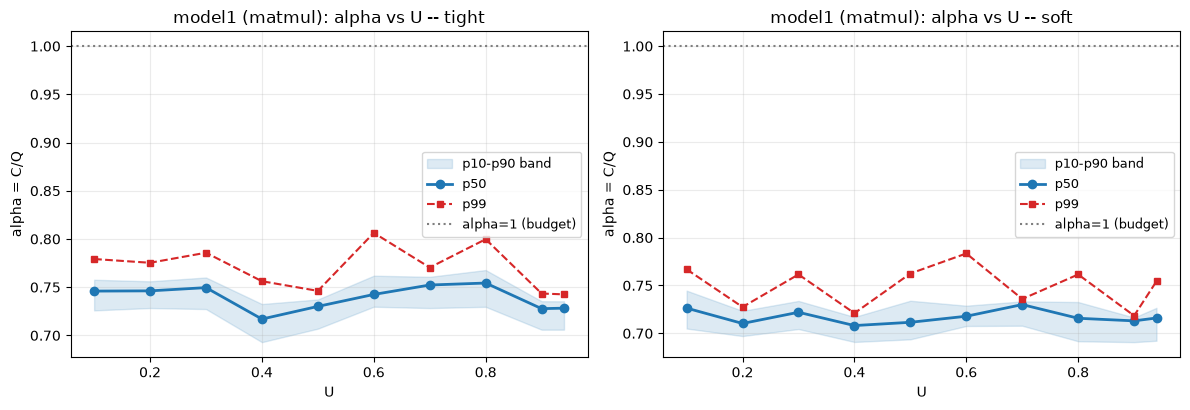

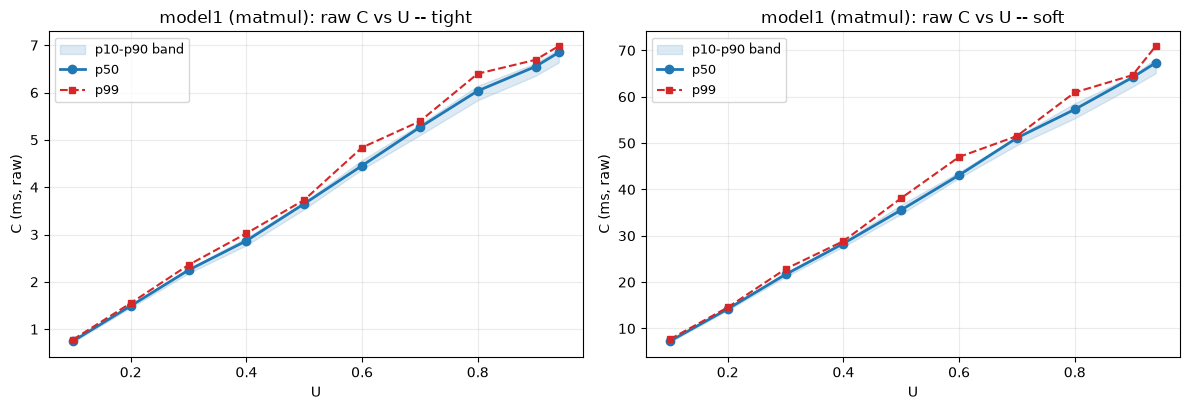

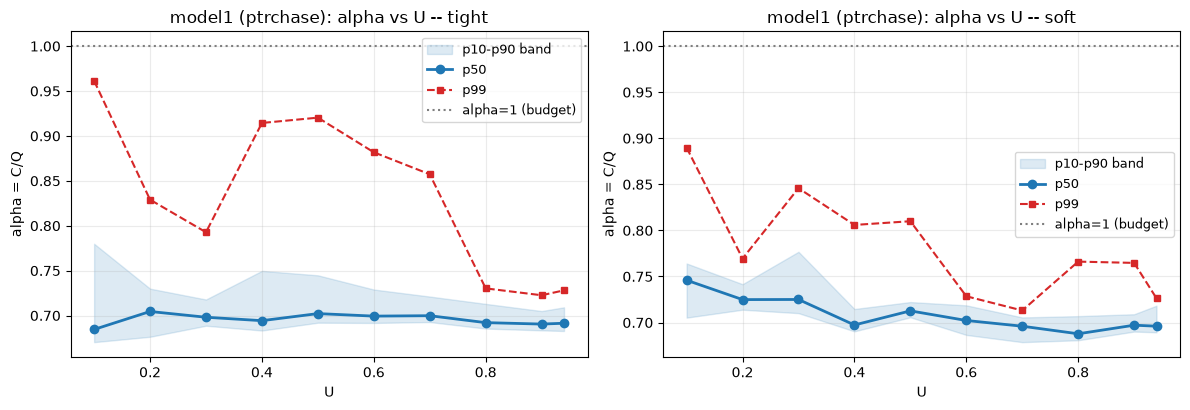

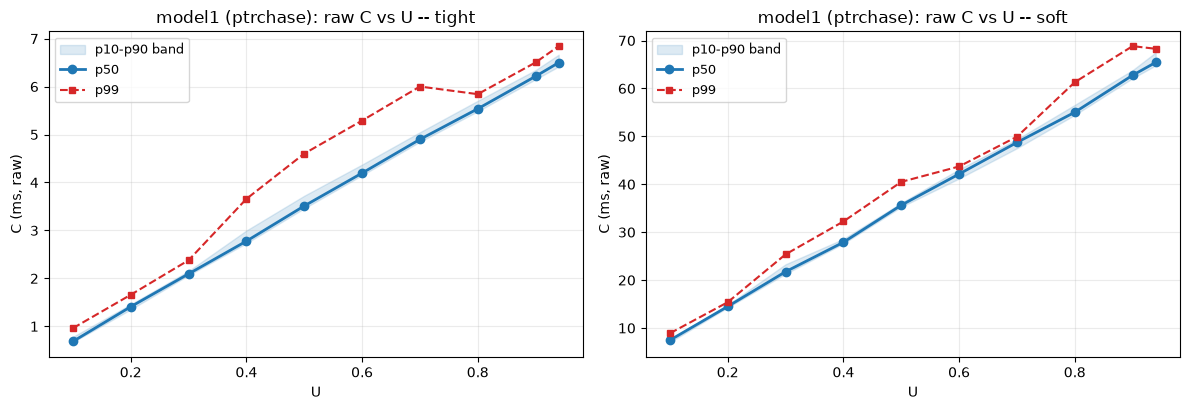

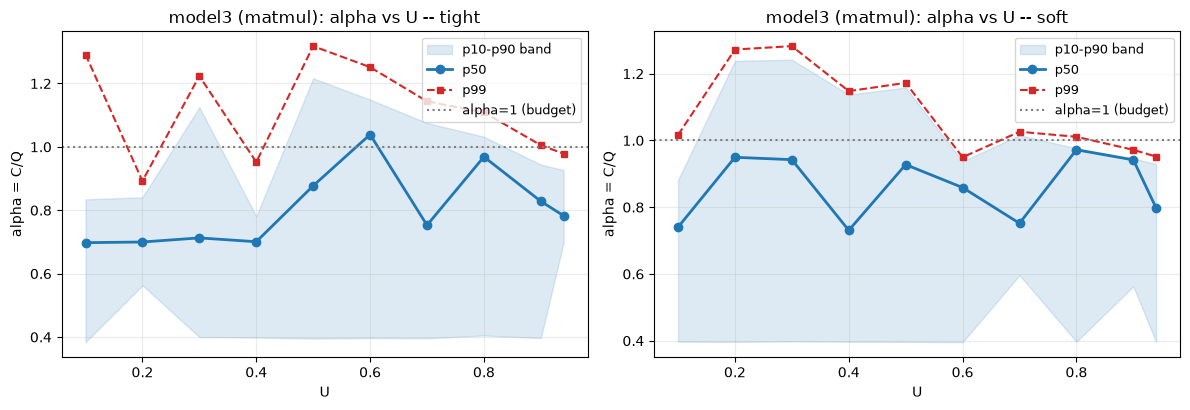

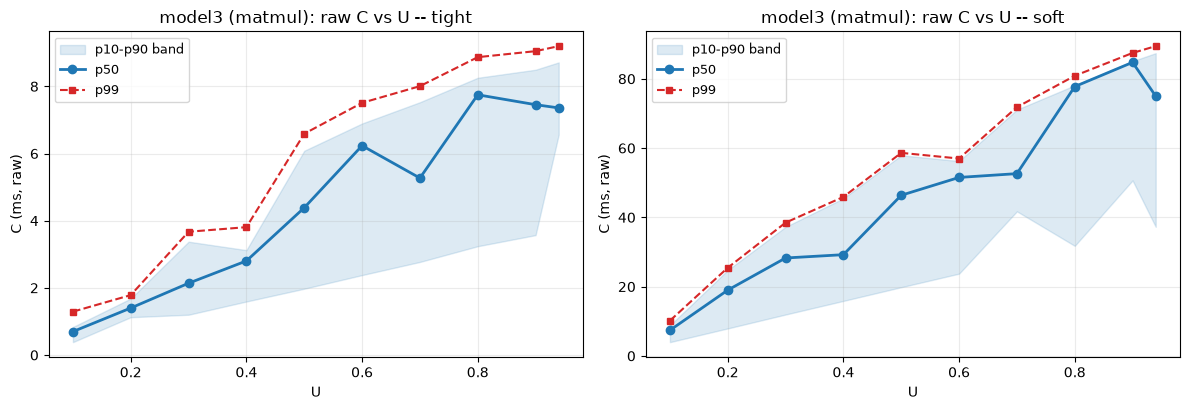

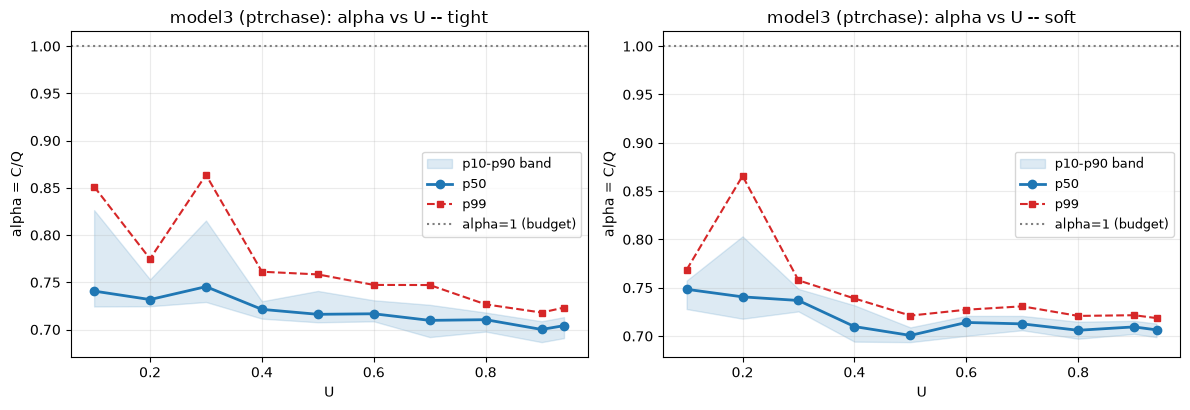

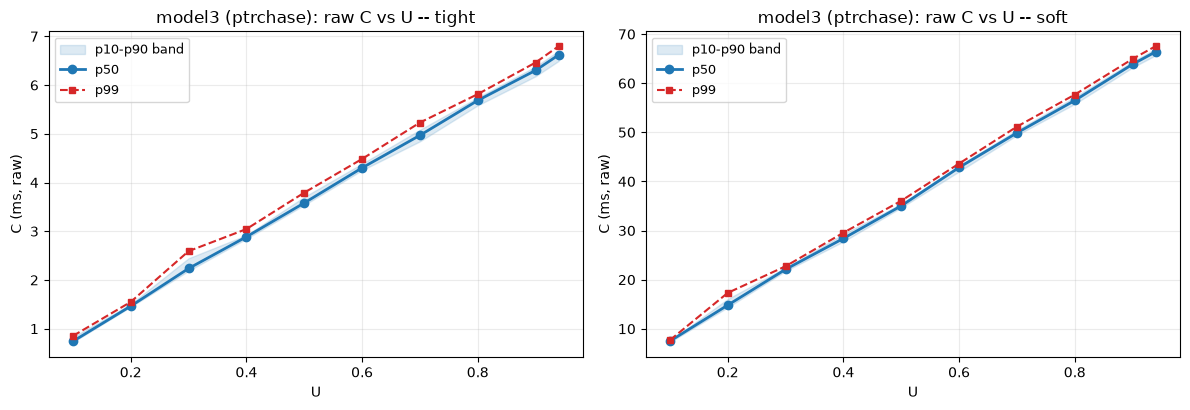

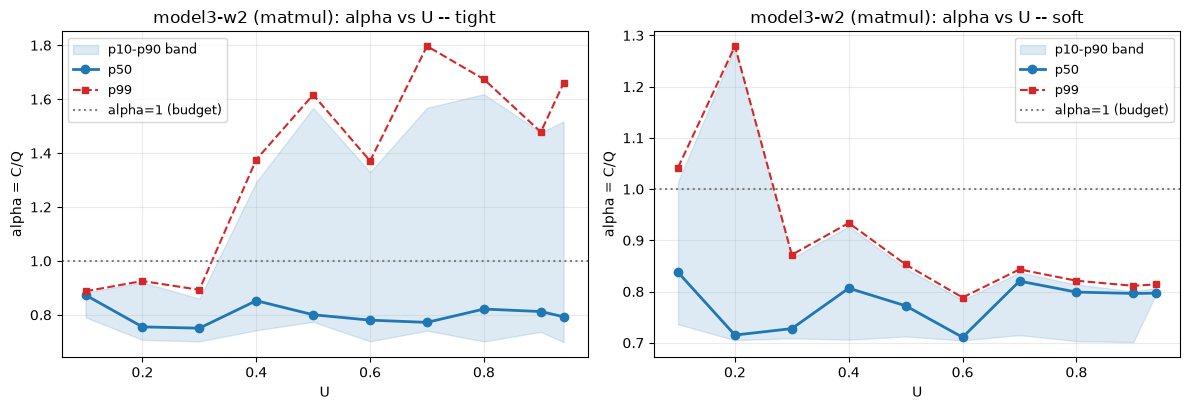

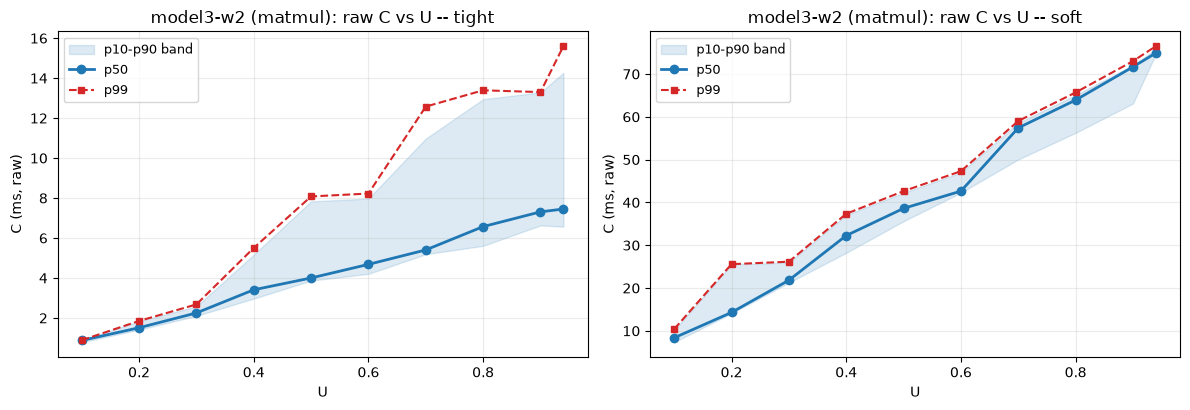

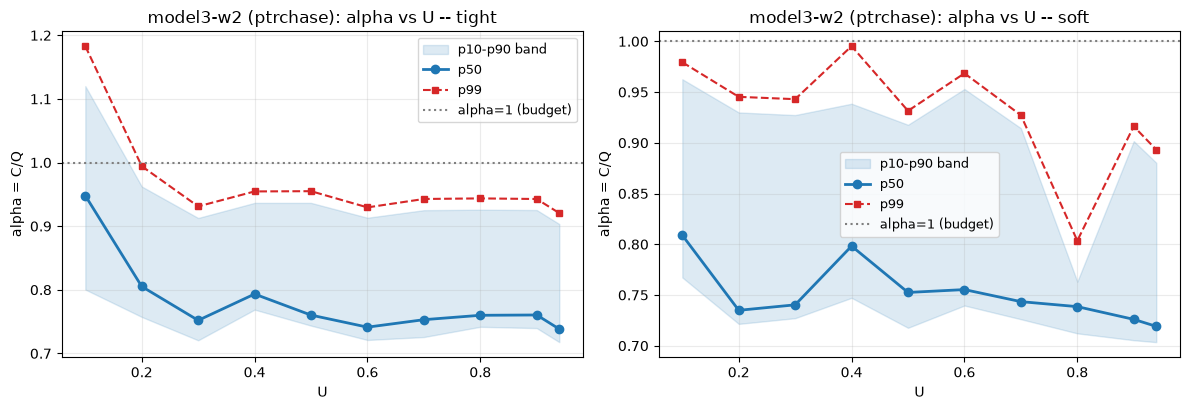

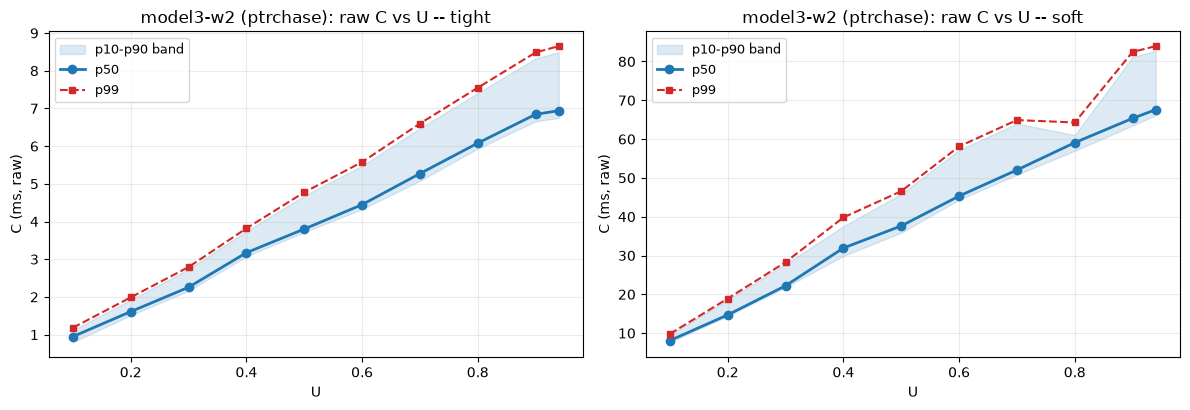

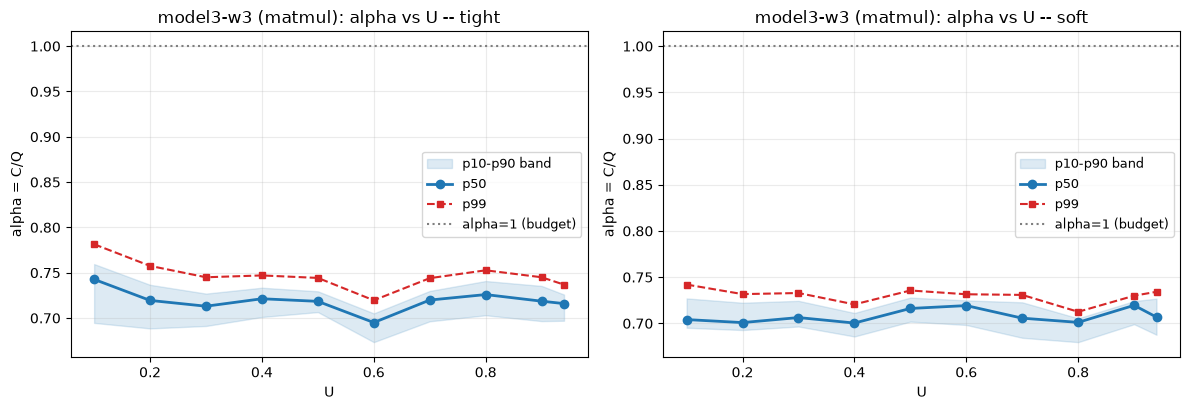

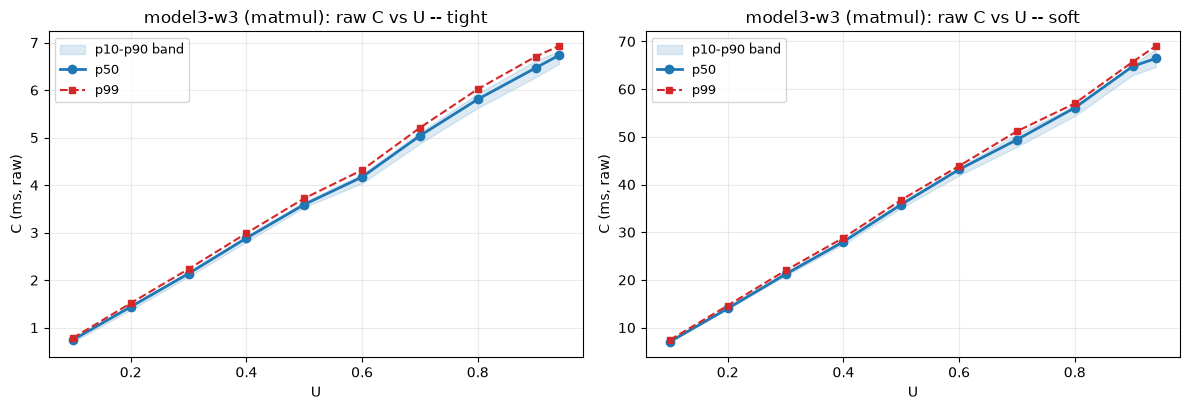

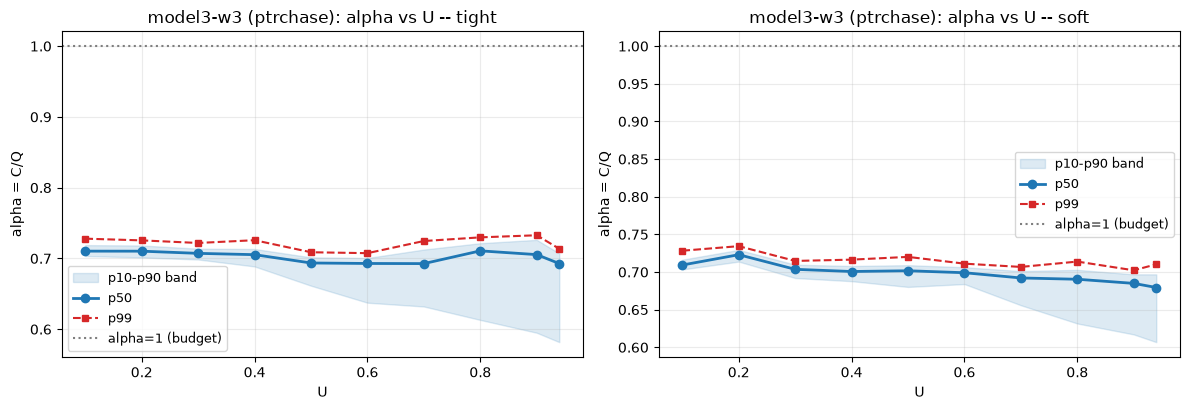

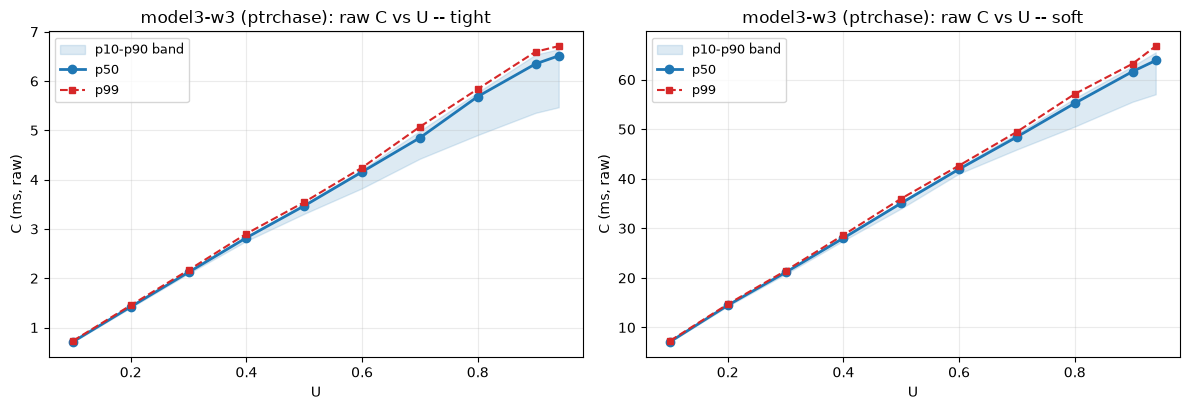

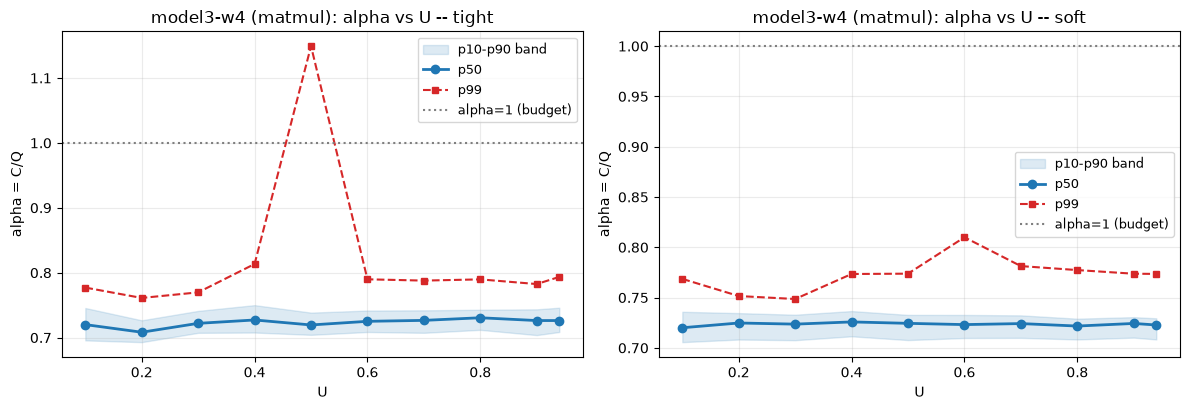

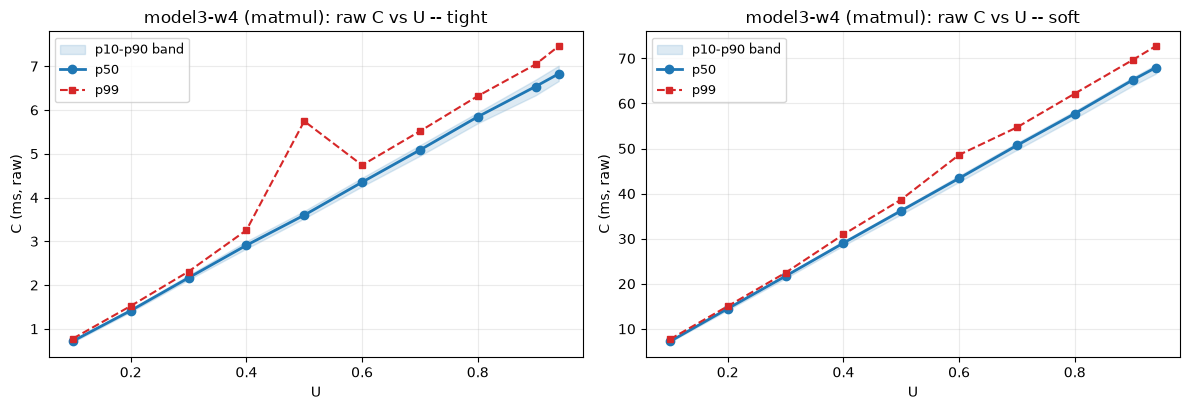

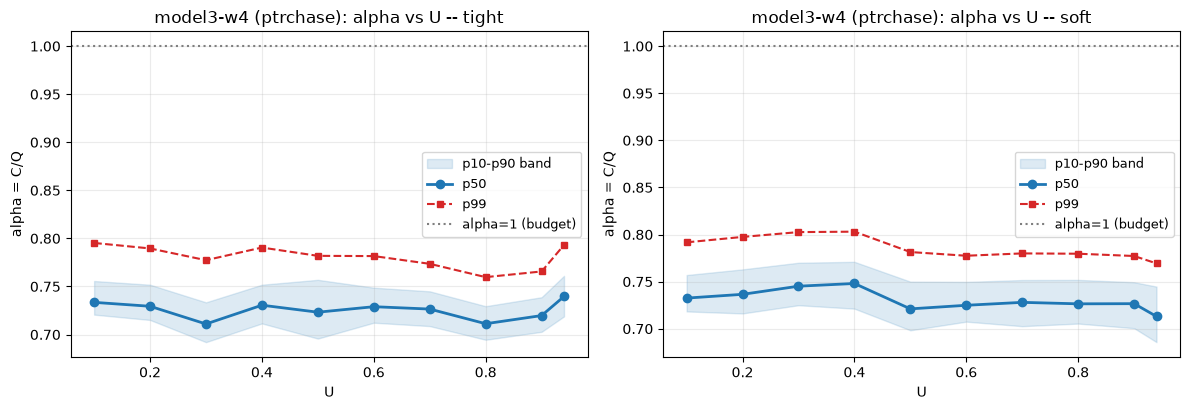

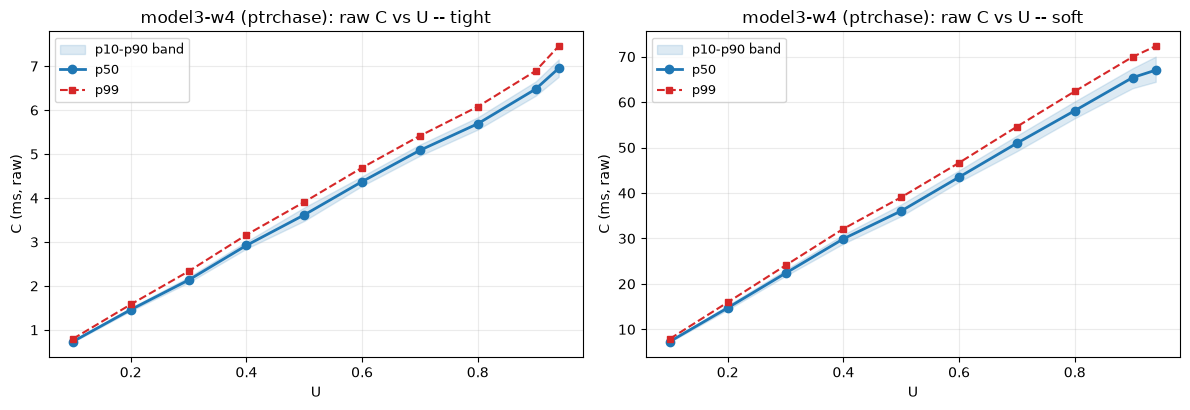

In [9]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        al.plot_vs_u(df, "alpha", "alpha = C/Q", f"{m} ({k}): alpha vs U", hline=1, hline_label="alpha=1 (budget)")
        al.plot_vs_u(df, "C_cputime_ms", "C (ms, raw)", f"{m} ({k}): raw C vs U")

### B.2 delta (normalized) and raw added latency (R−C), vs U

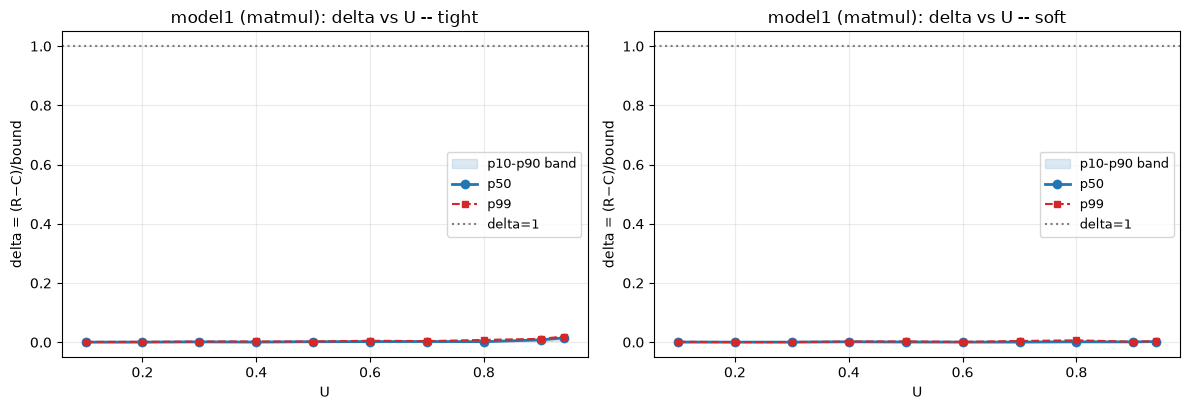

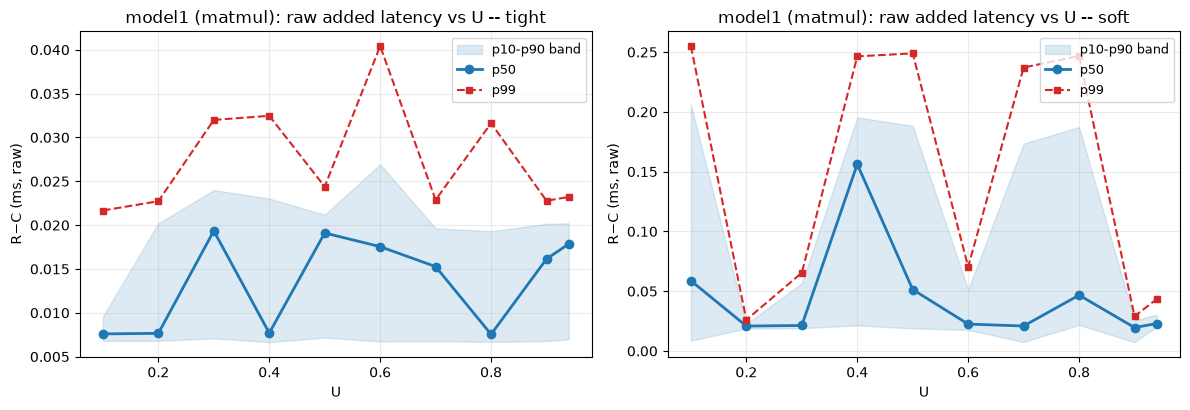

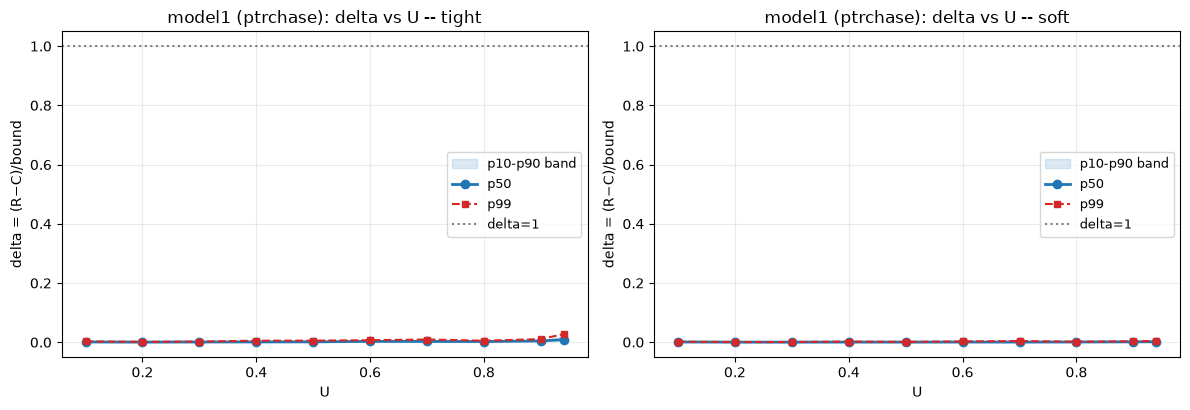

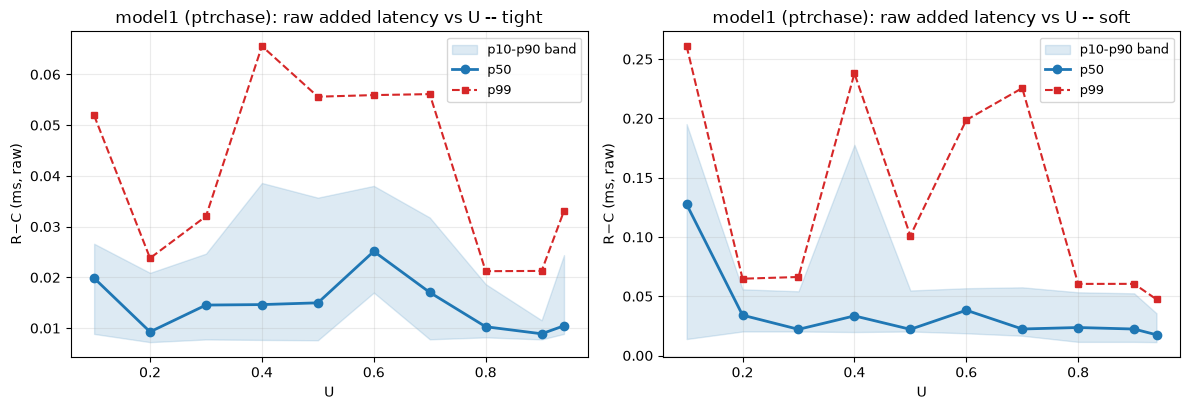

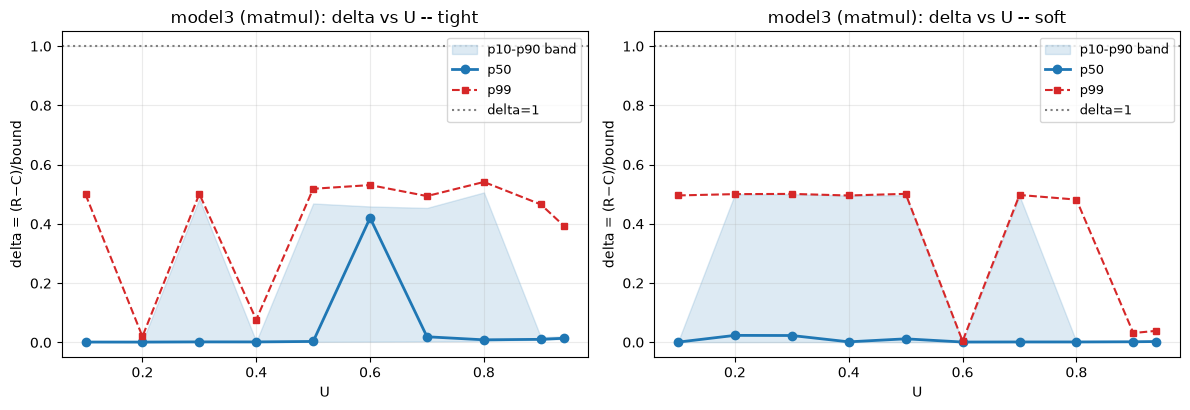

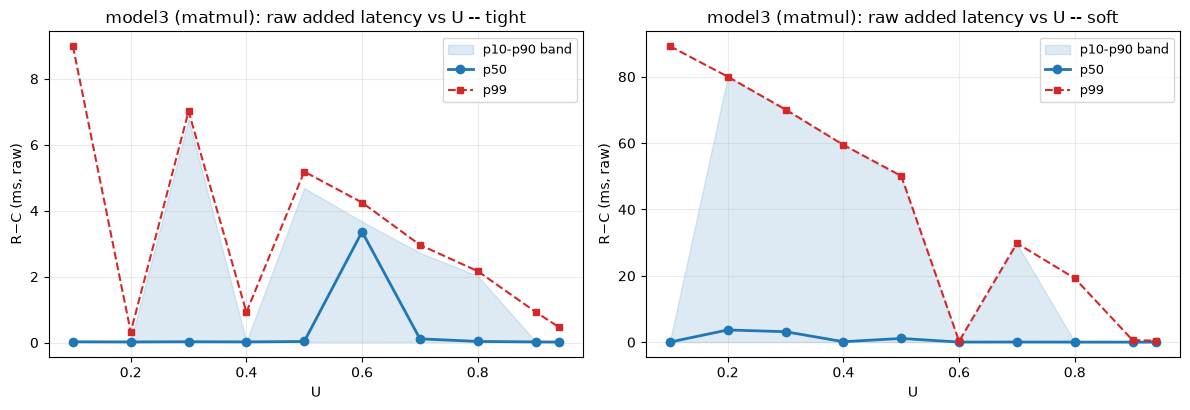

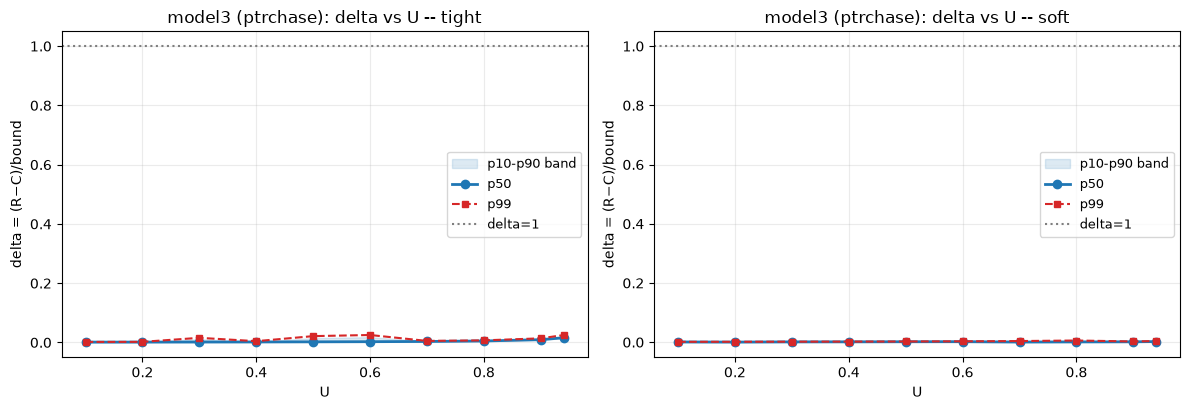

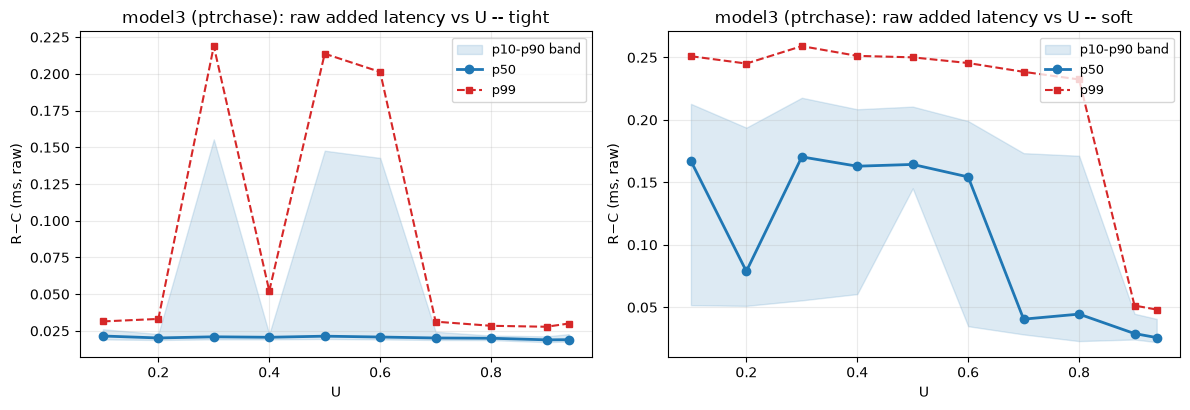

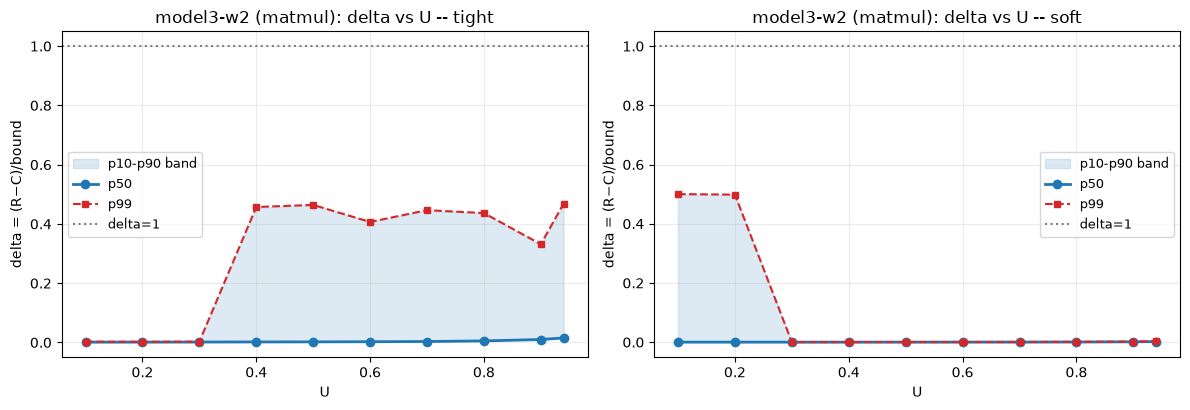

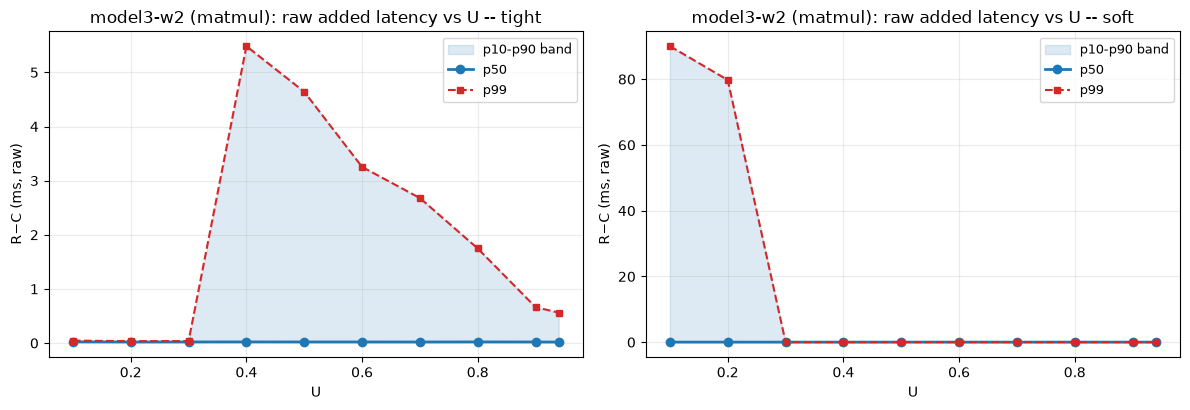

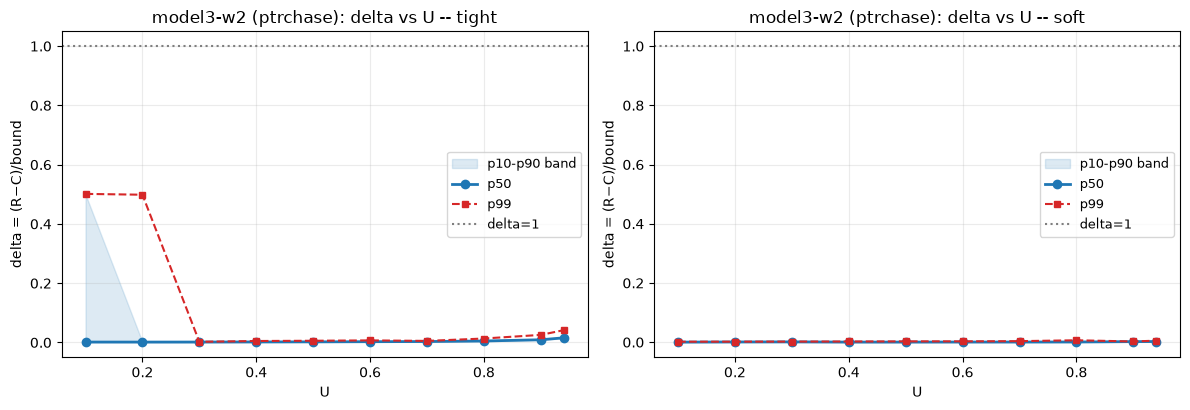

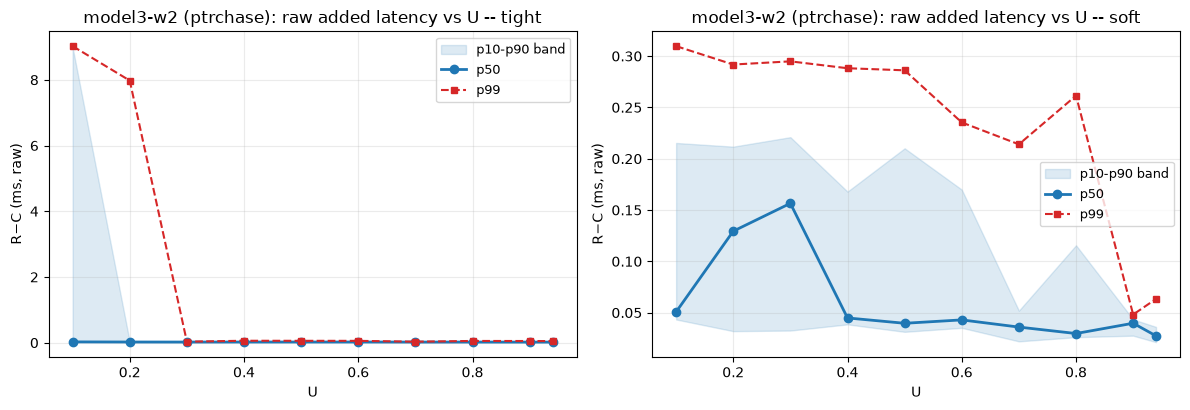

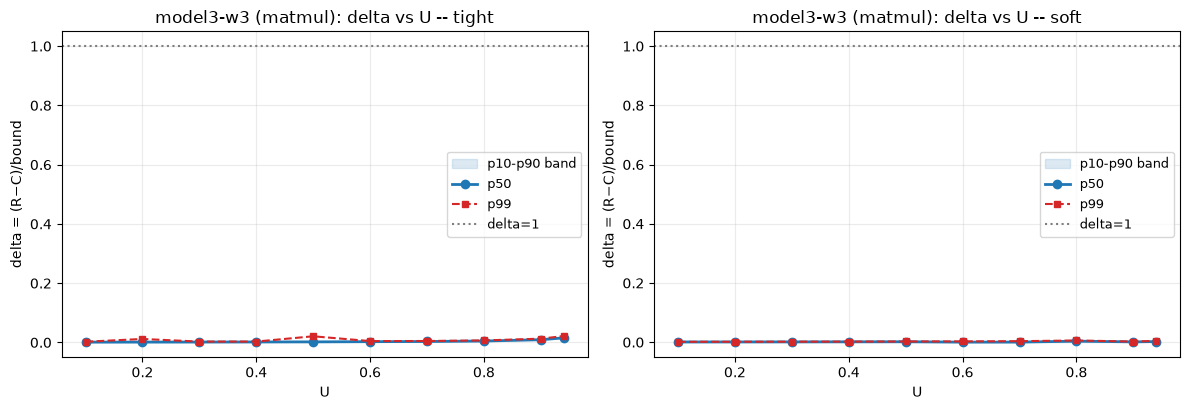

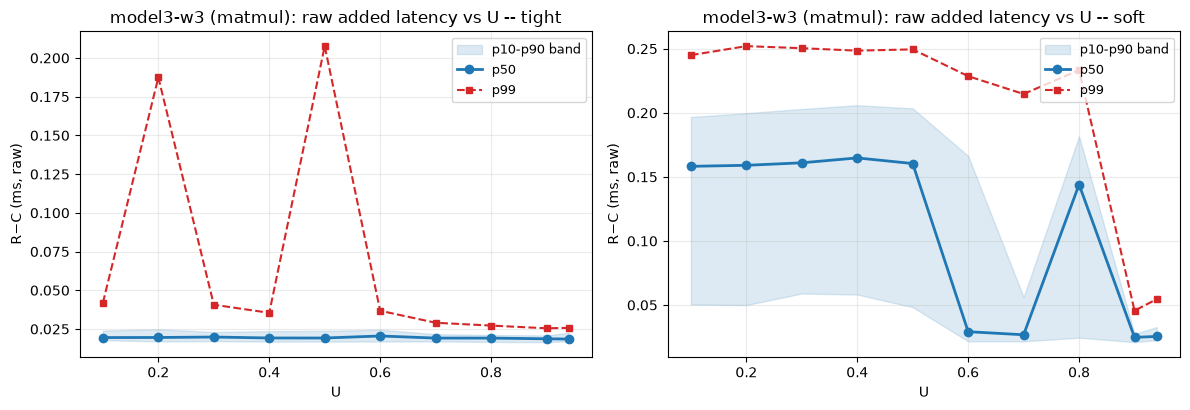

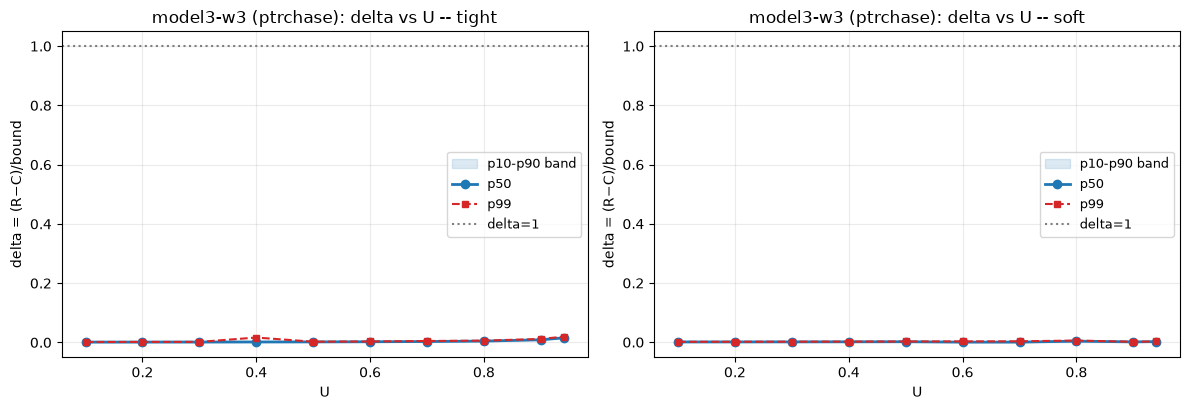

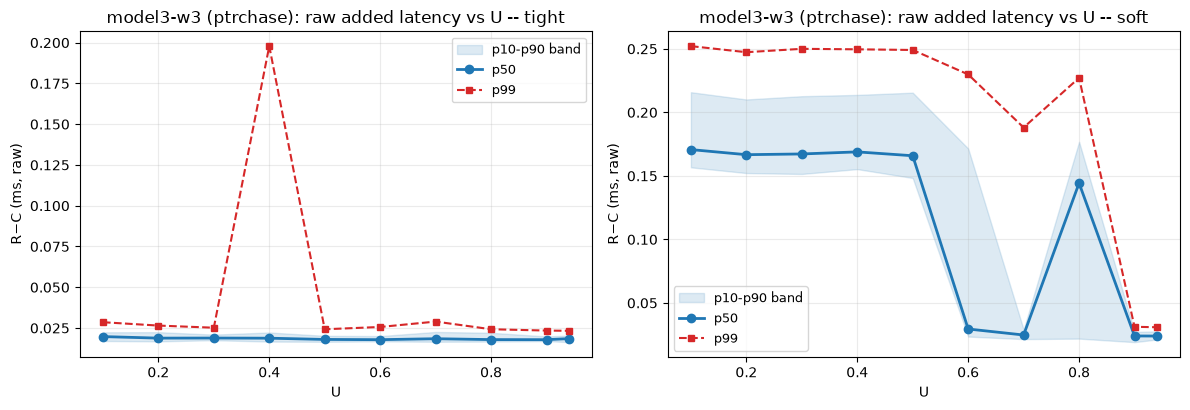

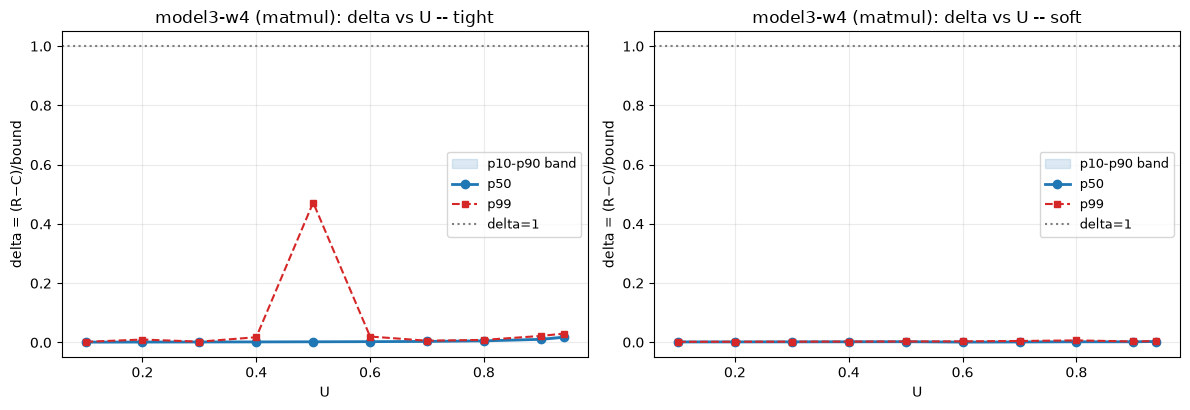

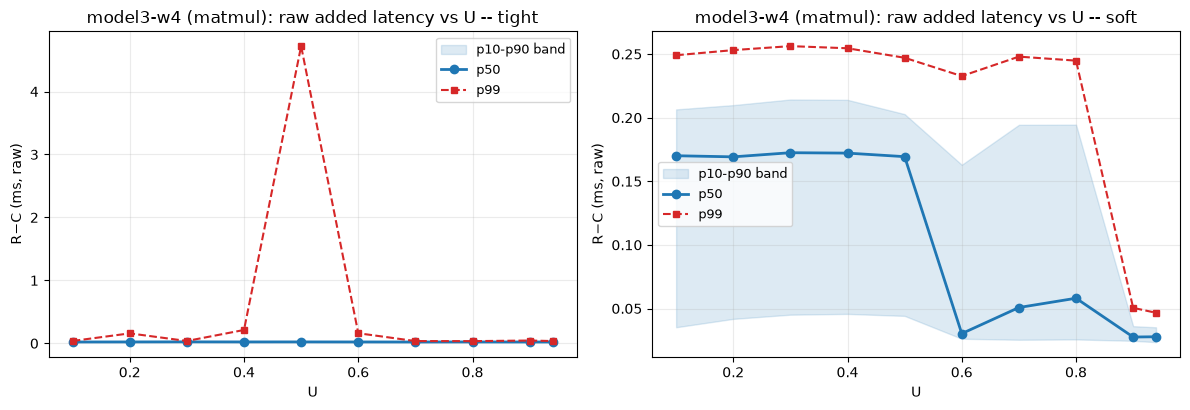

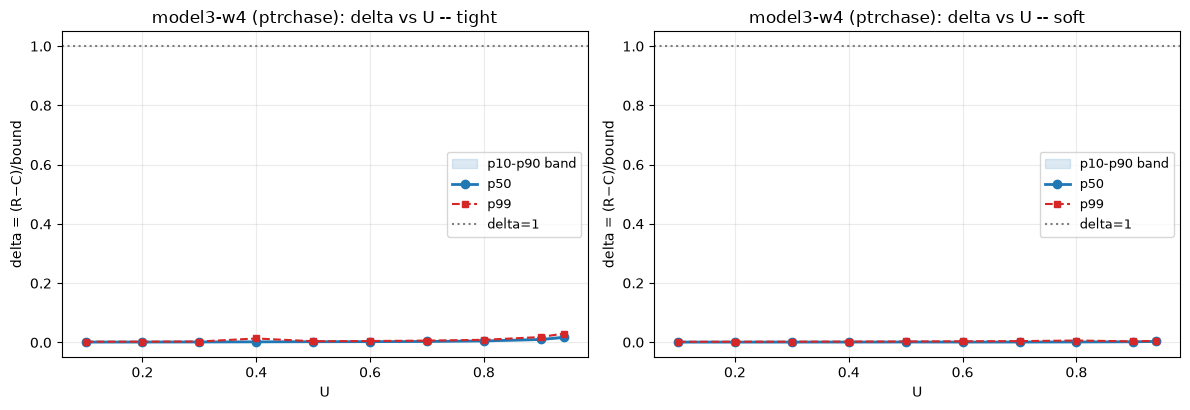

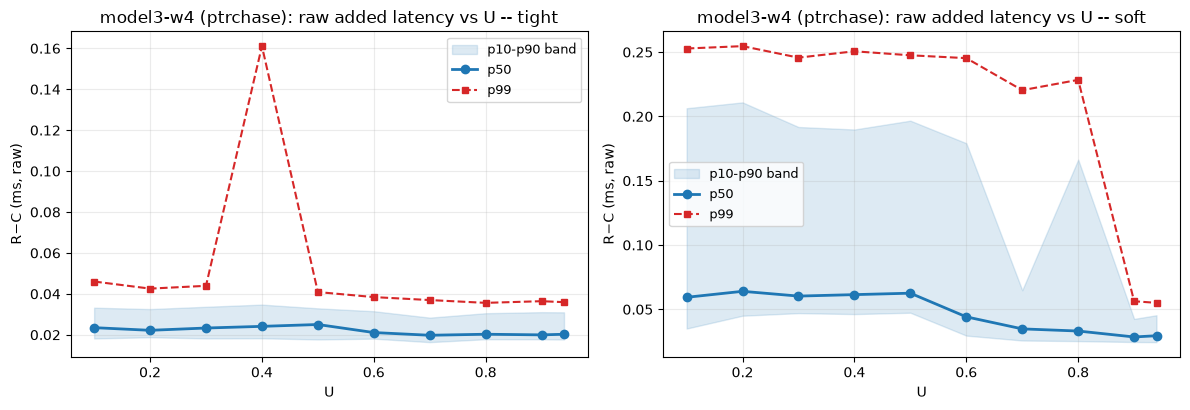

In [10]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        al.plot_vs_u(df, "delta", "delta = (R−C)/bound", f"{m} ({k}): delta vs U", hline=1, hline_label="delta=1")
        al.plot_vs_u(df, "added_latency_ms", "R−C (ms, raw)", f"{m} ({k}): raw added latency vs U")

### B.3 Deadline miss rate vs U

^ model1 (matmul)


^ model1 (ptrchase)


^ model3 (matmul)


^ model3 (ptrchase)


^ model3-w2 (matmul)
^ model3-w2 (ptrchase)


^ model3-w3 (matmul)


^ model3-w3 (ptrchase)
^ model3-w4 (matmul)


^ model3-w4 (ptrchase)


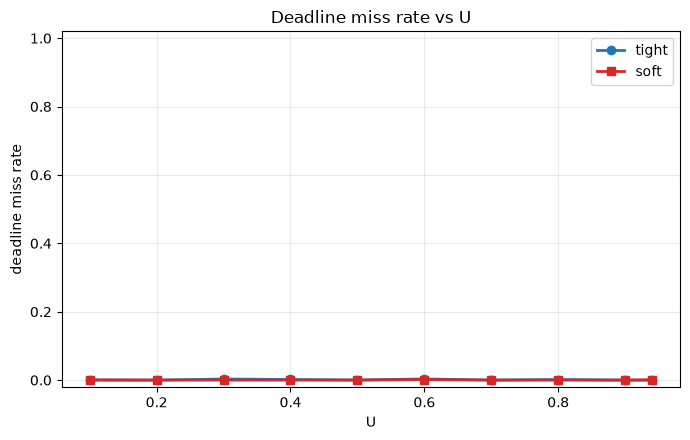

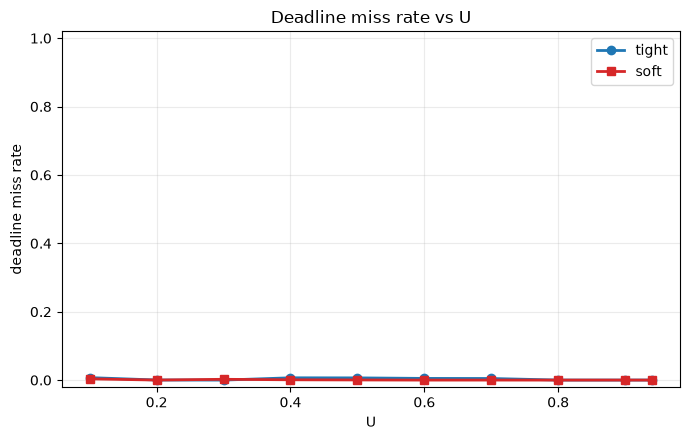

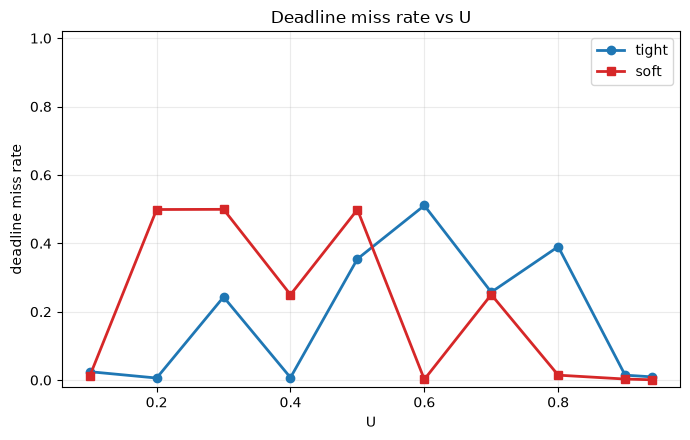

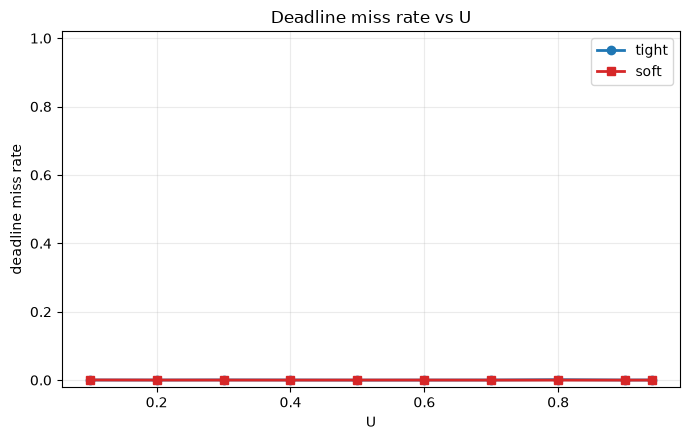

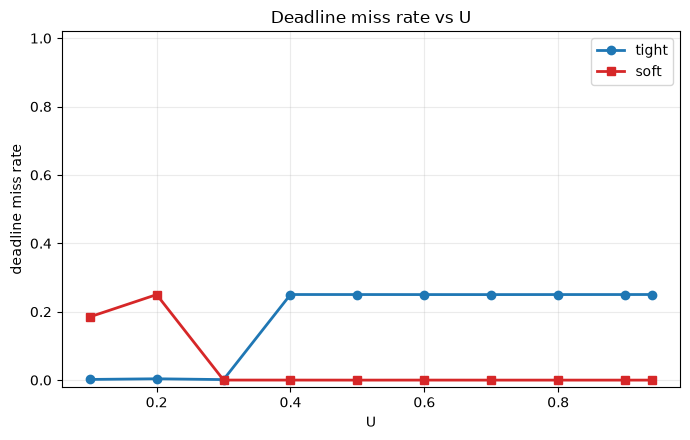

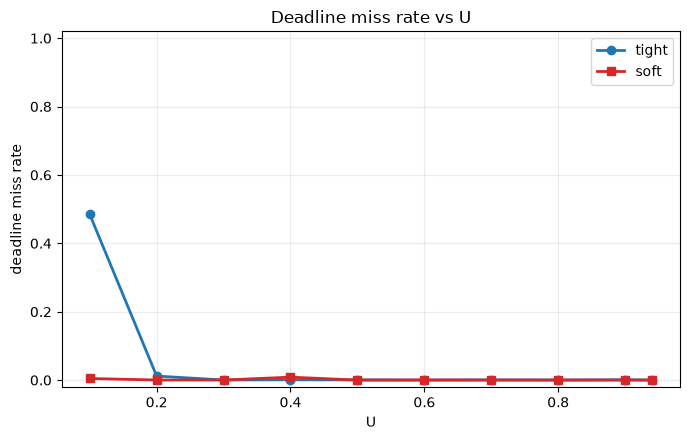

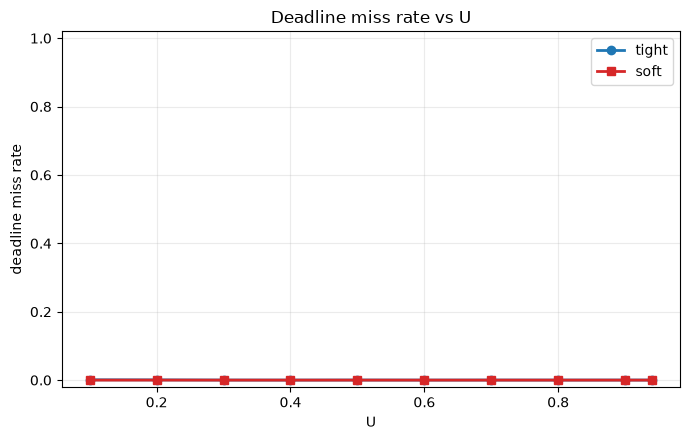

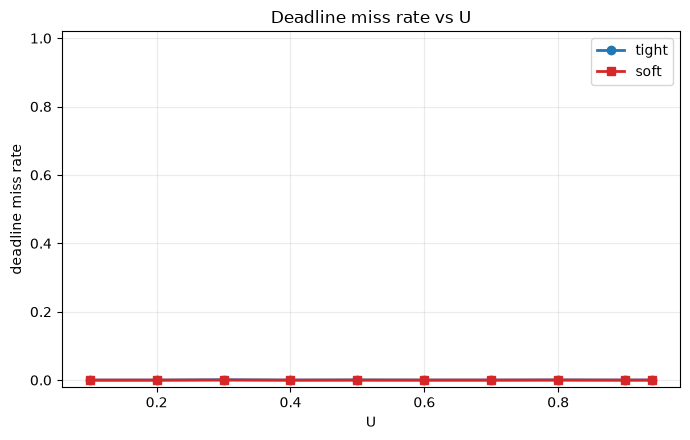

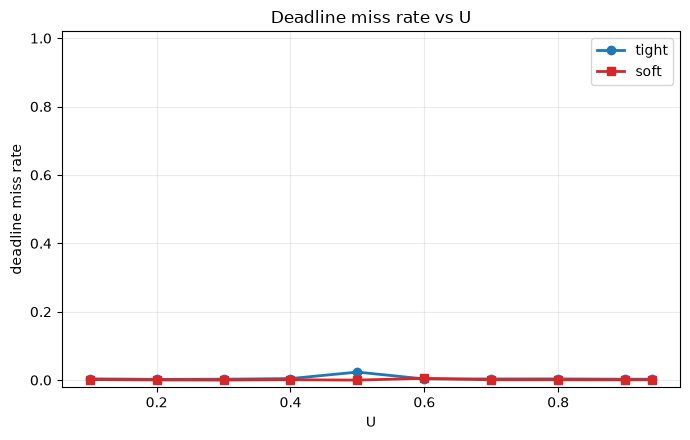

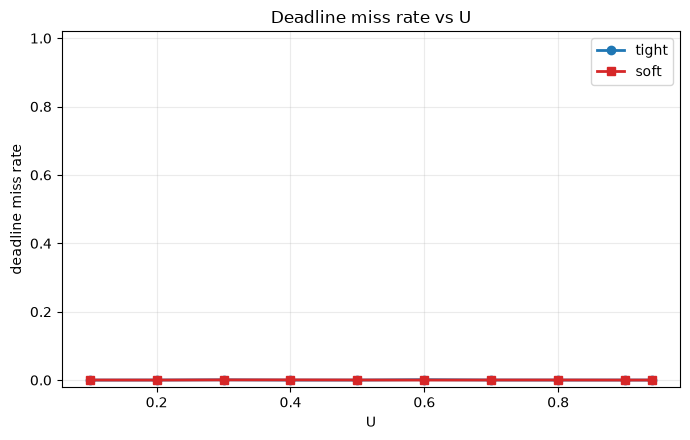

In [11]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        al.miss_rate_vs_u(df)
        print(f"^ {m} ({k})")

### B.4 p50 / p99 of R and C together, vs U
Same unit (ms) so one y-axis; color = R vs C, linestyle = p50 vs p99. Never a second y-axis for a same-unit second series.

^ model1 (matmul)


^ model1 (ptrchase)


^ model3 (matmul)


^ model3 (ptrchase)


^ model3-w2 (matmul)


^ model3-w2 (ptrchase)


^ model3-w3 (matmul)


^ model3-w3 (ptrchase)


^ model3-w4 (matmul)


^ model3-w4 (ptrchase)


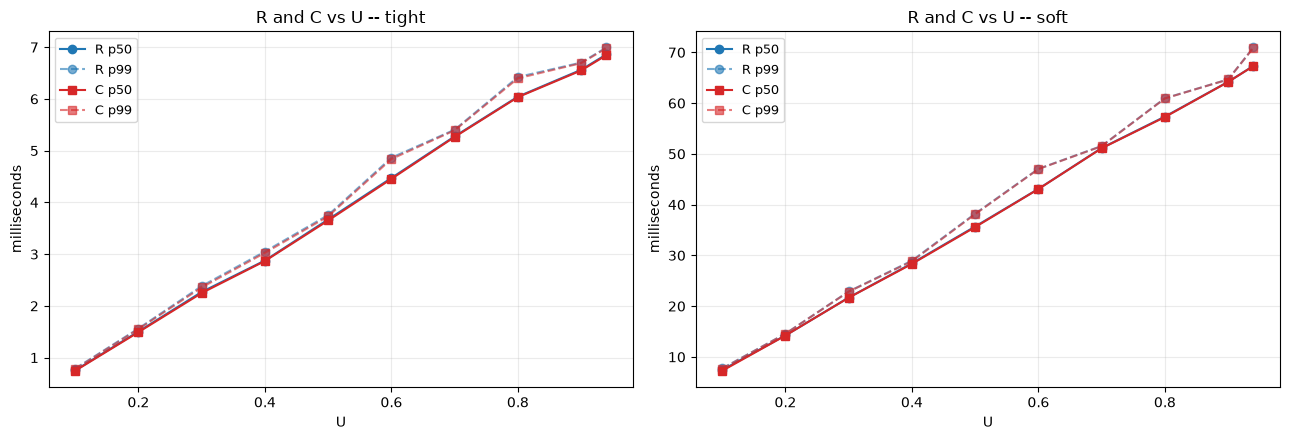

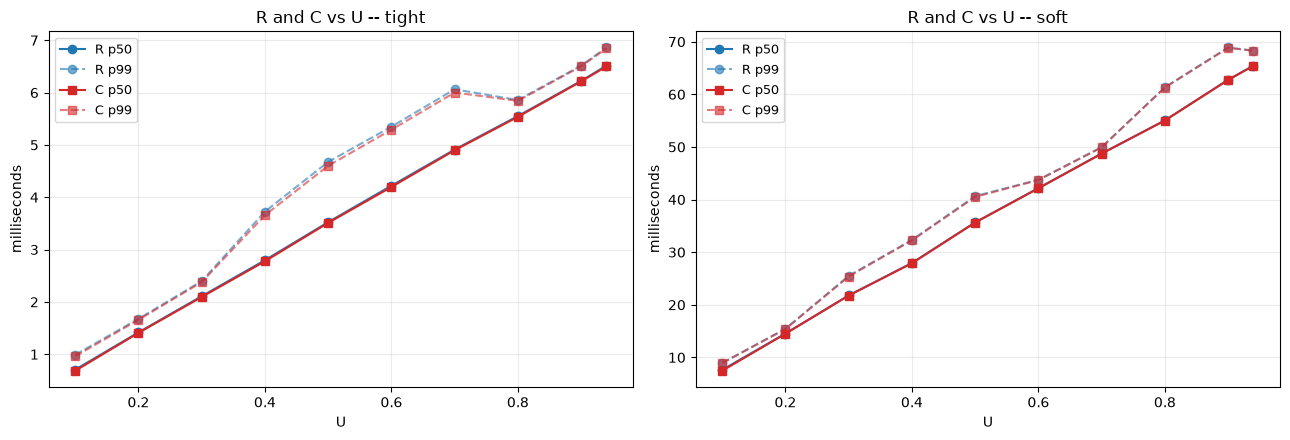

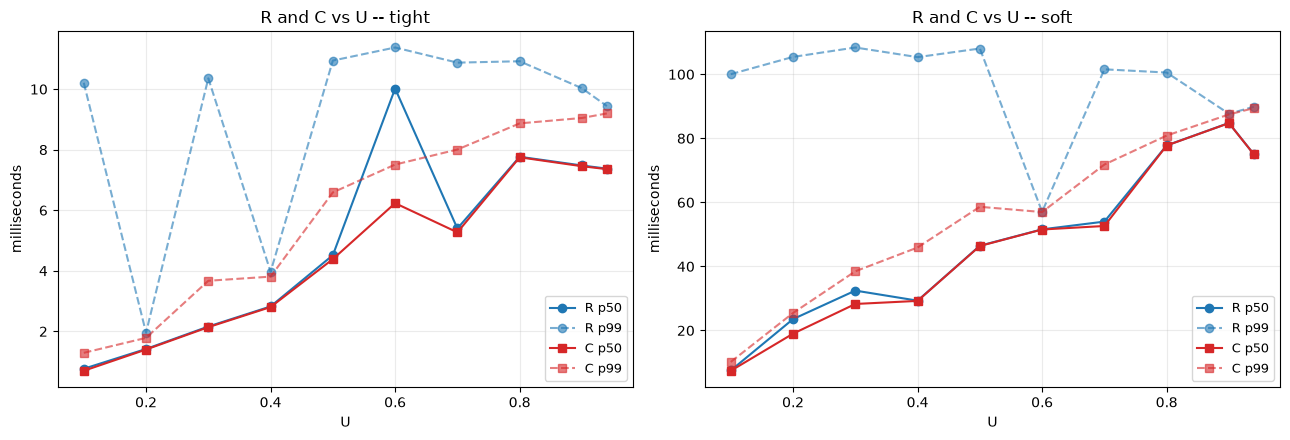

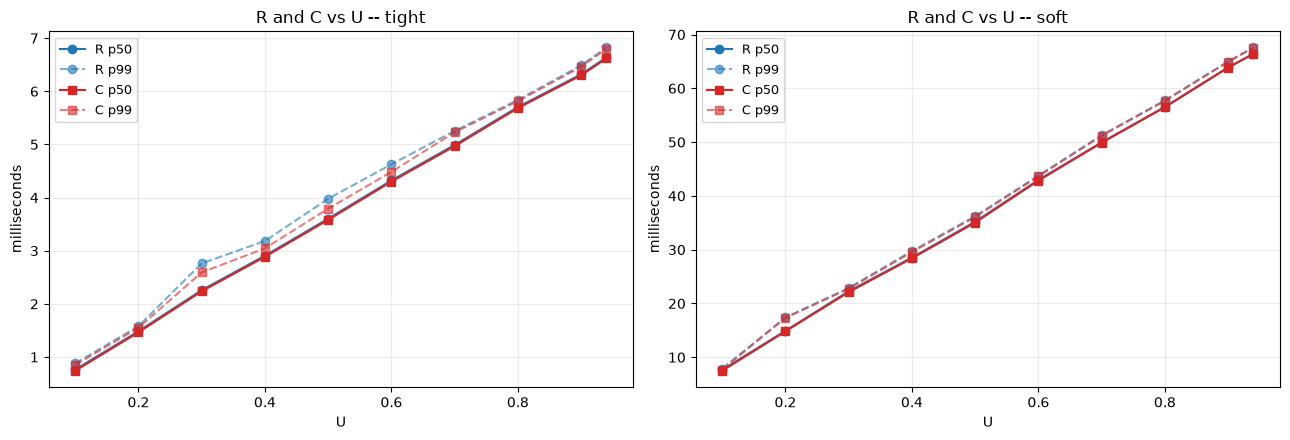

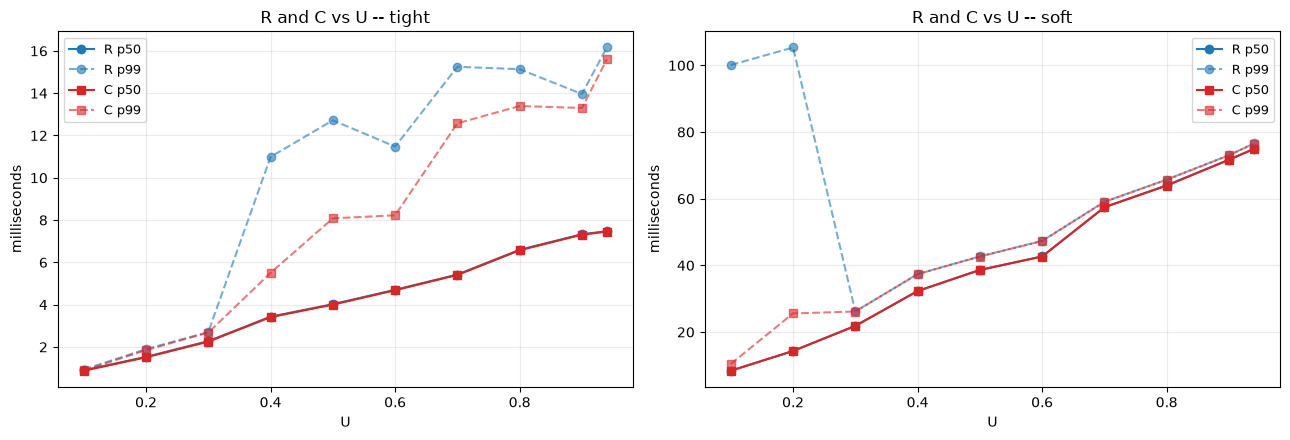

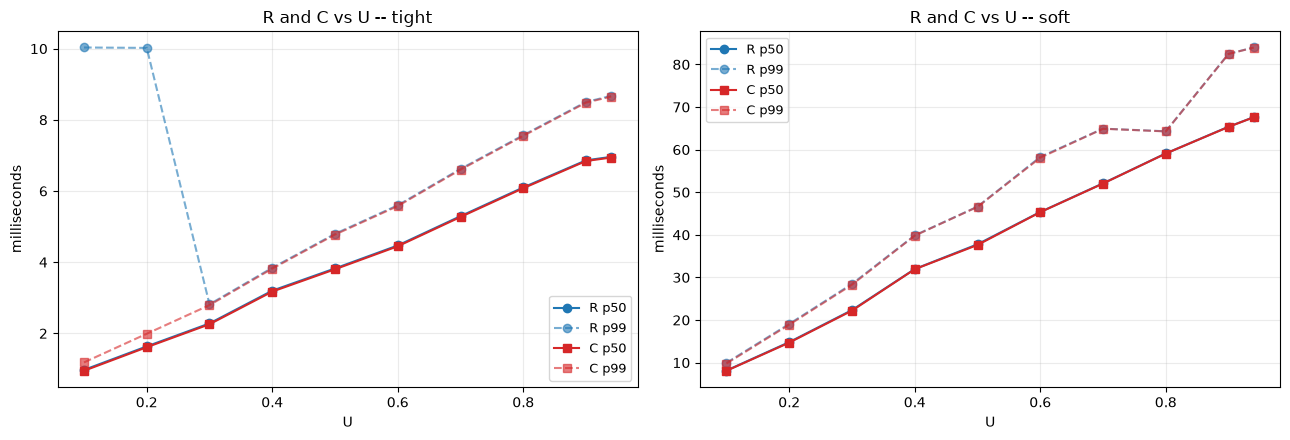

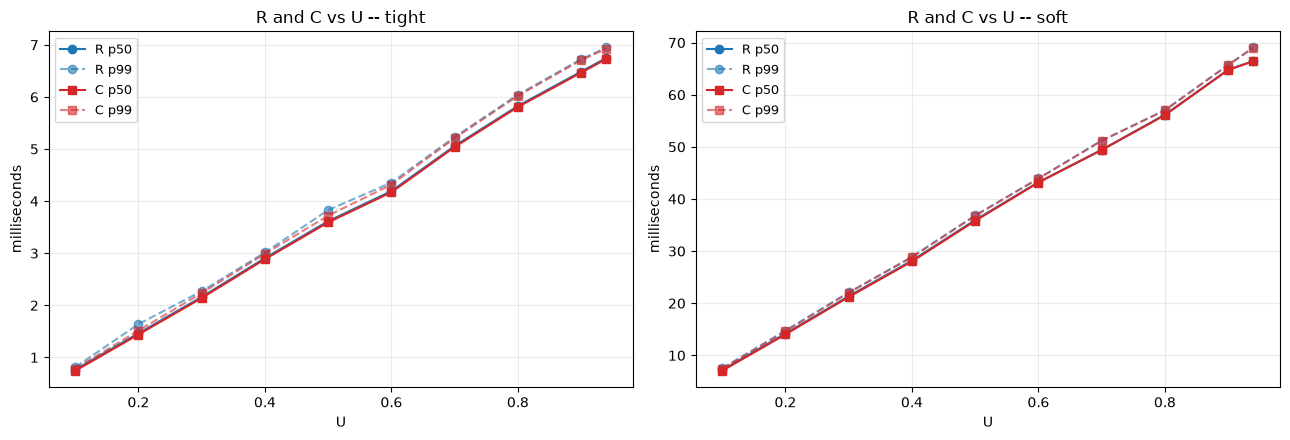

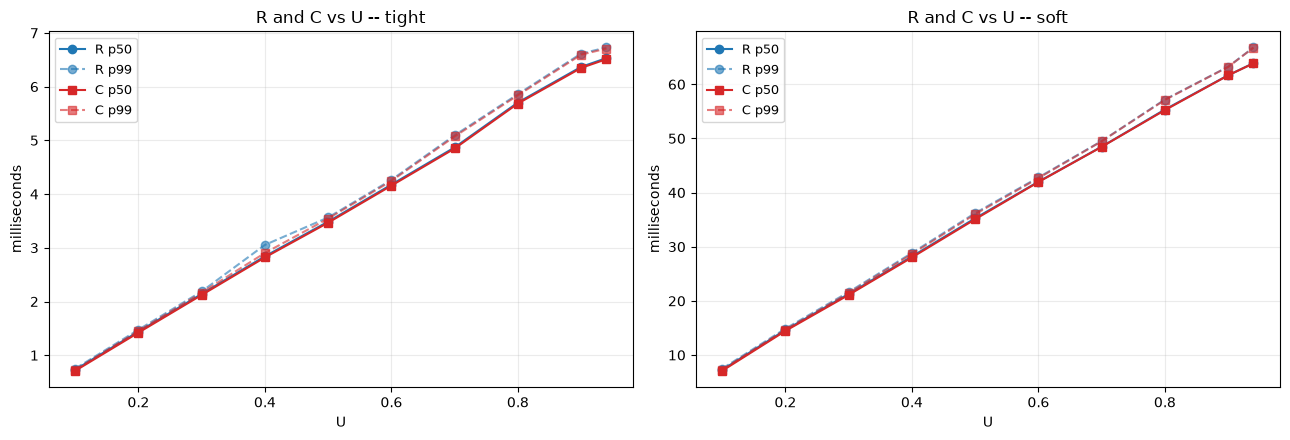

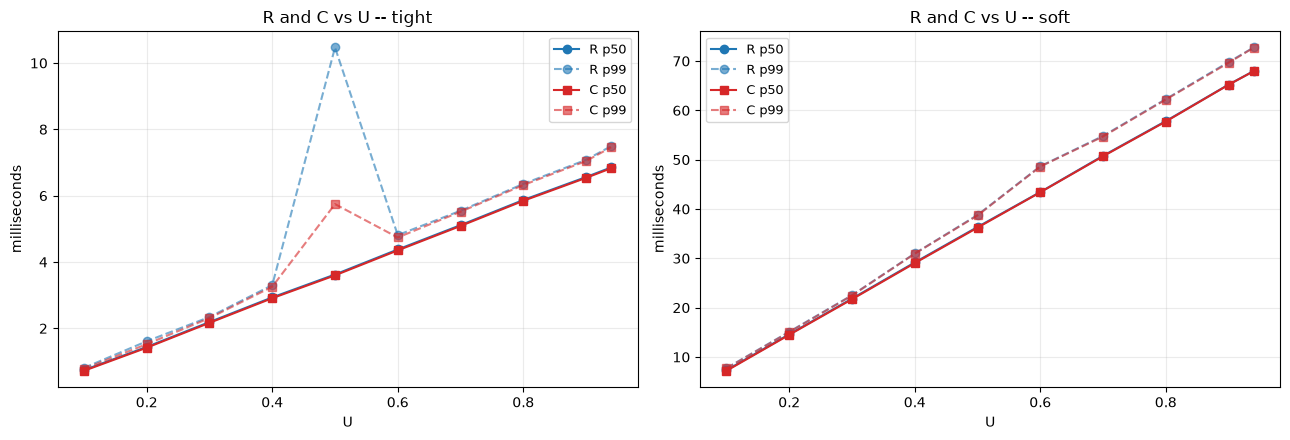

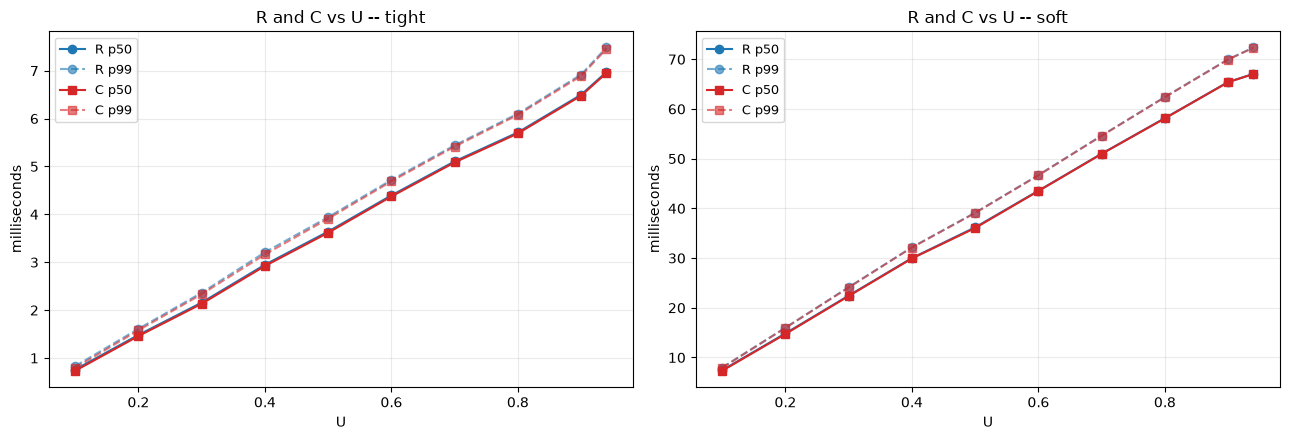

In [12]:
for m in MODELS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        al.rc_percentiles_vs_u(df)
        print(f"^ {m} ({k})")

## Section C — matmul vs ptrchase (workload comparison)

Every arm above ran both workloads through the identical placement/contention
setup, so the gap between them isolates one thing: how much a given
contention mechanism (SMT-sibling sharing, an unreserved vs reserved
co-runner, physical-core isolation) actually bites a **compute-bound**
workload (matmul, saturates shared execution ports / cache bandwidth) versus
a **memory-latency-bound** one (ptrchase, mostly stalled on dependent loads —
SMT is specifically good at hiding that kind of stall with a sibling's work,
so less contention should reach it in the first place).

### C.1 C_p50 and miss rate side by side, plus the C_p50 ratio (ptrchase / matmul)

In [13]:
for m in MODELS:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    print(f"=== {m} ===")
    display(al.kind_comparison_table(df))

=== model1 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.264,7.460,0.0006,0.0036,1.027
1,soft,0.20,14.206,14.499,0.0000,0.0001,1.021
2,soft,0.30,21.660,21.752,0.0001,0.0024,1.004
3,soft,0.40,28.325,27.895,0.0000,0.0010,0.985
4,soft,0.50,35.577,35.635,0.0001,0.0004,1.002
5,soft,0.60,43.072,42.136,0.0017,0.0000,0.978
6,soft,0.70,51.103,48.723,0.0000,0.0001,0.953
7,soft,0.80,57.260,55.026,0.0000,0.0000,0.961
8,soft,0.90,64.174,62.743,0.0000,0.0001,0.978
9,soft,0.94,67.309,65.431,0.0008,0.0000,0.972


=== model3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.401,7.484,0.0116,0.0004,1.011
1,soft,0.20,18.989,14.812,0.4989,0.0001,0.780
2,soft,0.30,28.270,22.105,0.4994,0.0001,0.782
3,soft,0.40,29.227,28.394,0.2498,0.0000,0.971
4,soft,0.50,46.377,35.034,0.4986,0.0001,0.755
5,soft,0.60,51.528,42.845,0.0021,0.0001,0.831
6,soft,0.70,52.625,49.883,0.2500,0.0000,0.948
7,soft,0.80,77.756,56.480,0.0145,0.0000,0.726
8,soft,0.90,84.753,63.854,0.0031,0.0000,0.753
9,soft,0.94,75.006,66.404,0.0010,0.0000,0.885


=== model3-w2 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,8.376,8.089,0.1848,0.0047,0.966
1,soft,0.20,14.302,14.698,0.2500,0.0002,1.028
2,soft,0.30,21.831,22.209,0.0001,0.0003,1.017
3,soft,0.40,32.261,31.928,0.0001,0.0086,0.990
4,soft,0.50,38.611,37.625,0.0000,0.0001,0.974
5,soft,0.60,42.648,45.320,0.0000,0.0003,1.063
6,soft,0.70,57.424,52.041,0.0000,0.0002,0.906
7,soft,0.80,63.920,59.082,0.0000,0.0002,0.924
8,soft,0.90,71.670,65.339,0.0000,0.0001,0.912
9,soft,0.94,74.914,67.593,0.0000,0.0001,0.902


=== model3-w3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.041,7.093,0.0000,0.0000,1.007
1,soft,0.20,14.017,14.460,0.0000,0.0000,1.032
2,soft,0.30,21.189,21.108,0.0000,0.0000,0.996
3,soft,0.40,28.014,28.028,0.0000,0.0000,1.000
4,soft,0.50,35.807,35.084,0.0000,0.0000,0.980
5,soft,0.60,43.154,41.945,0.0000,0.0000,0.972
6,soft,0.70,49.394,48.449,0.0000,0.0001,0.981
7,soft,0.80,56.087,55.234,0.0000,0.0001,0.985
8,soft,0.90,64.757,61.644,0.0000,0.0000,0.952
9,soft,0.94,66.436,63.869,0.0000,0.0001,0.961


=== model3-w4 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.200,7.325,0.0016,0.0003,1.017
1,soft,0.20,14.495,14.730,0.0004,0.0001,1.016
2,soft,0.30,21.709,22.355,0.0001,0.0006,1.030
3,soft,0.40,29.033,29.921,0.0010,0.0006,1.031
4,soft,0.50,36.221,36.054,0.0000,0.0004,0.995
5,soft,0.60,43.390,43.494,0.0051,0.0001,1.002
6,soft,0.70,50.693,50.960,0.0008,0.0003,1.005
7,soft,0.80,57.738,58.115,0.0008,0.0004,1.007
8,soft,0.90,65.188,65.394,0.0006,0.0001,1.003
9,soft,0.94,67.941,67.028,0.0008,0.0002,0.987


### C.2 alpha and raw C vs U, matmul vs ptrchase overlaid

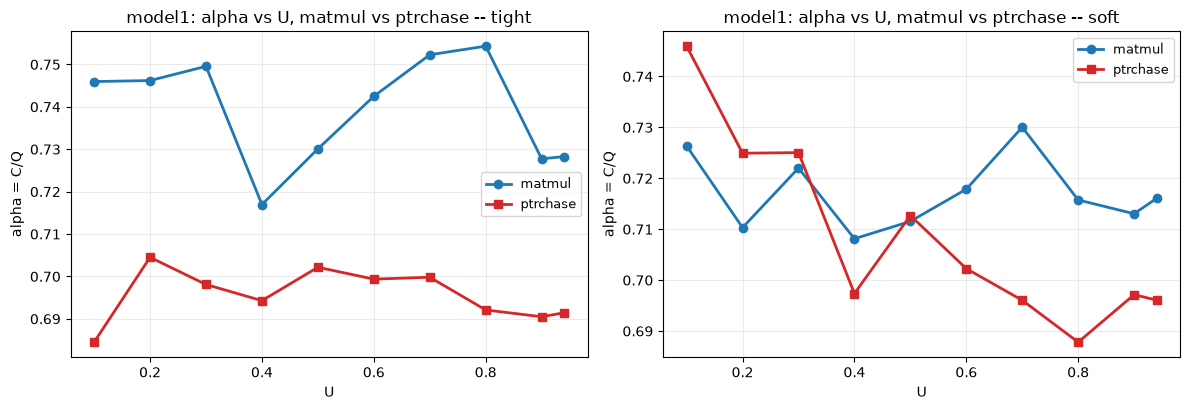

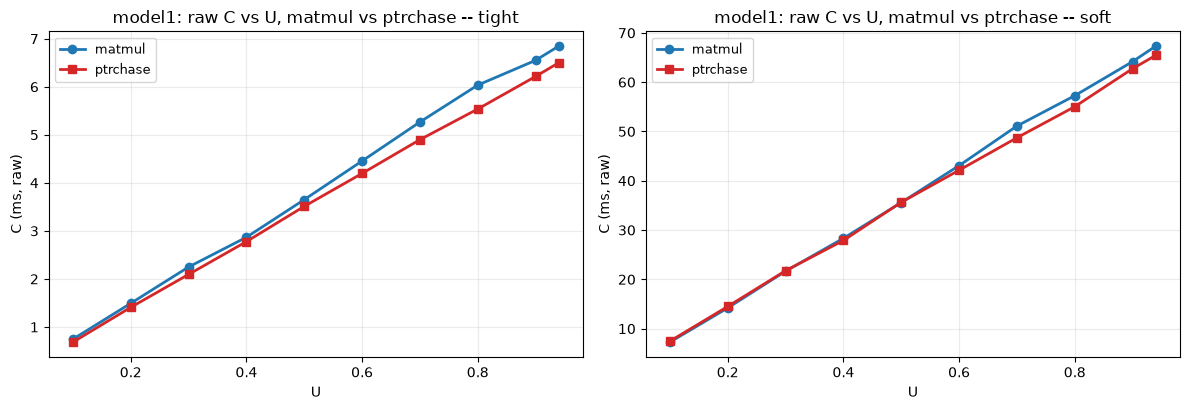

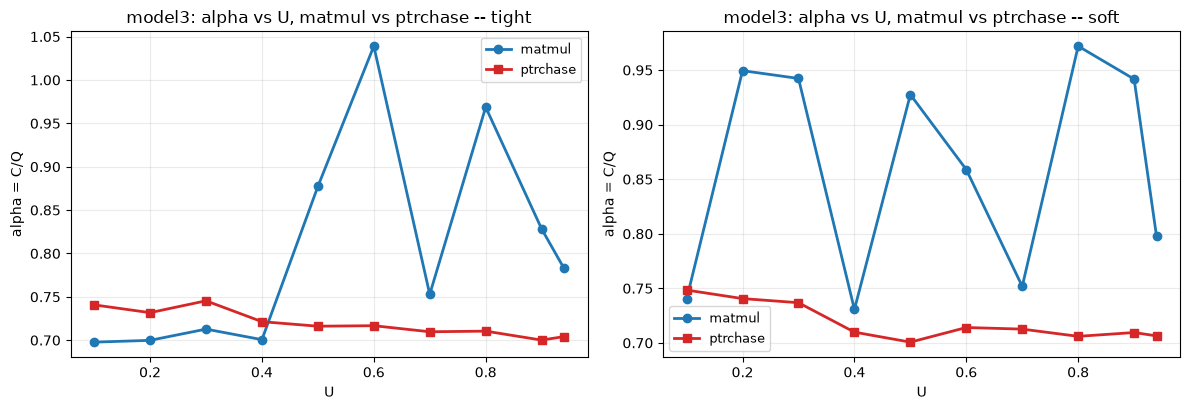

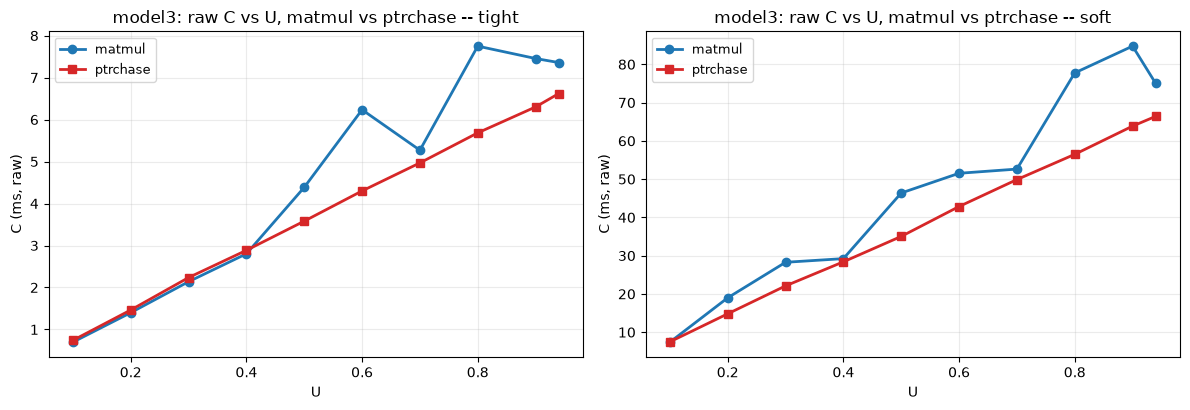

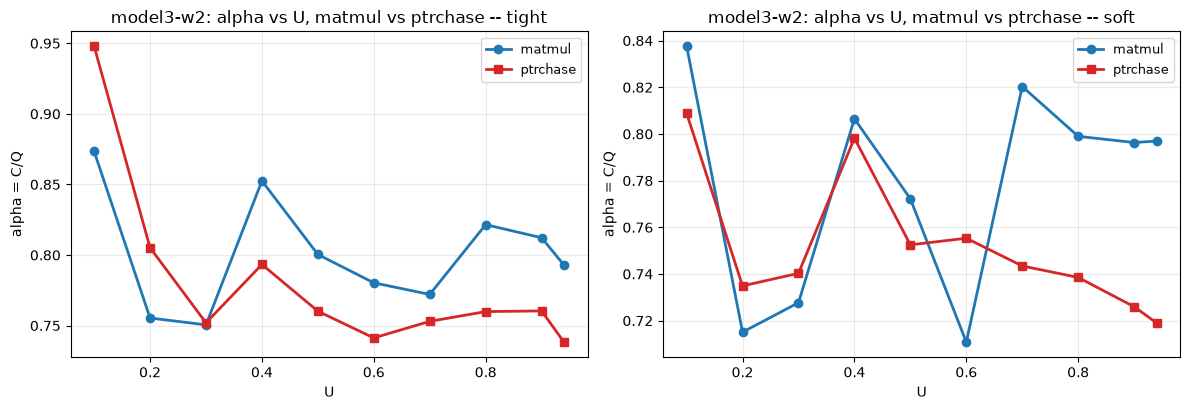

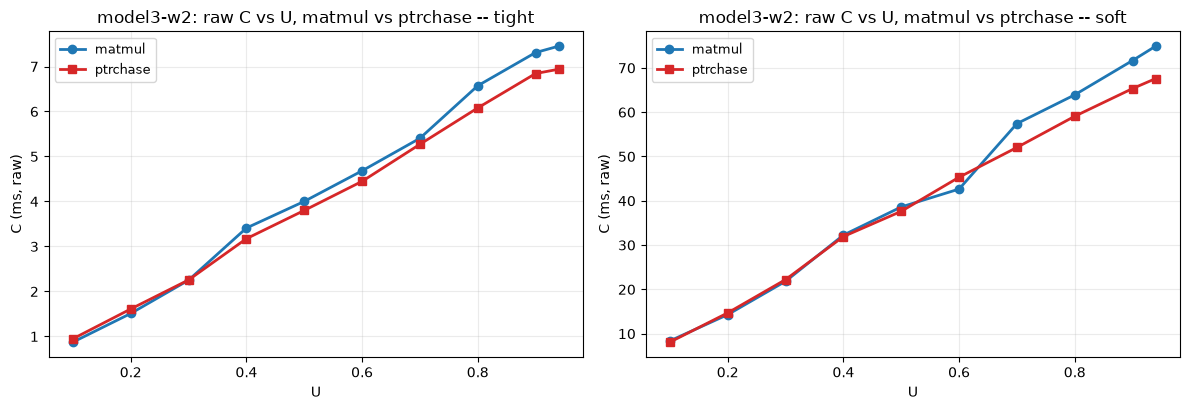

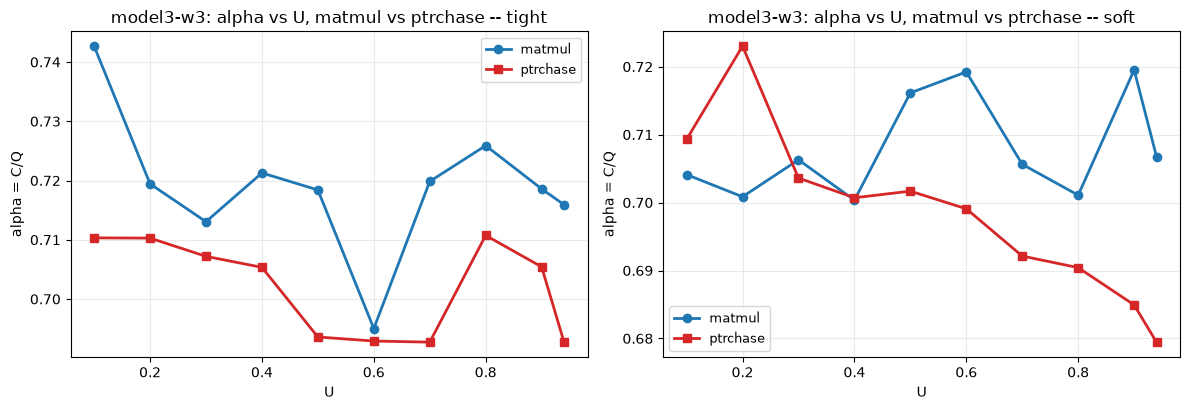

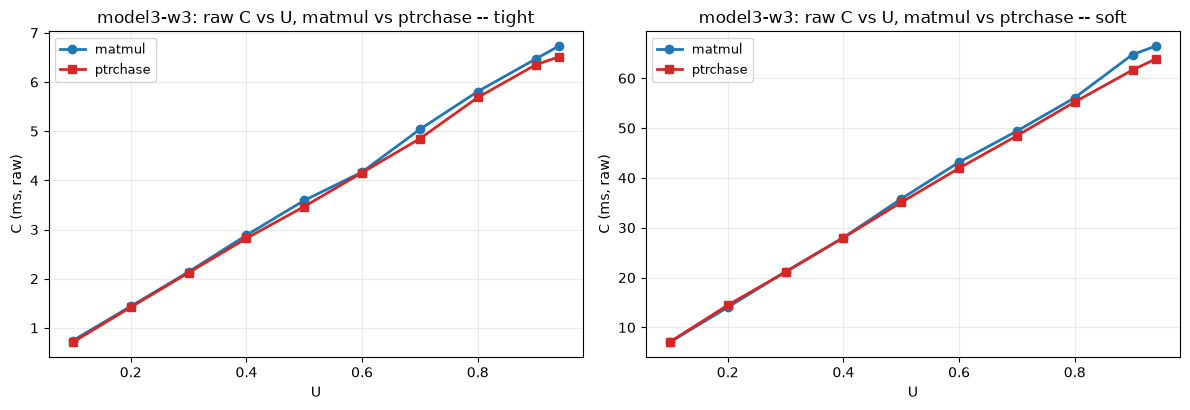

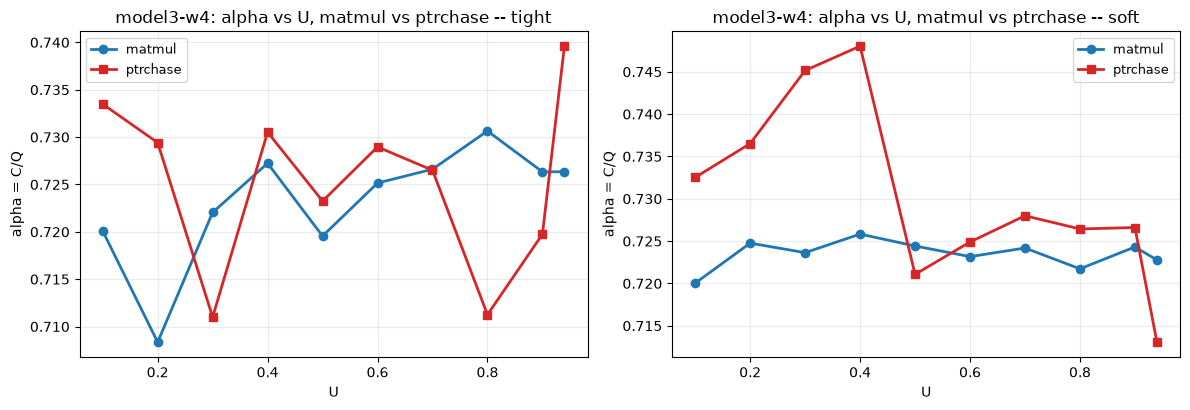

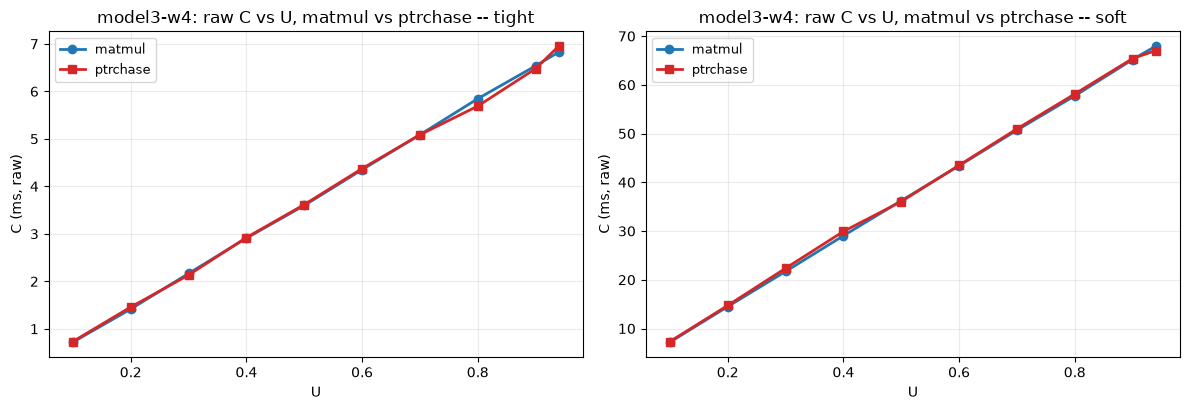

In [14]:
for m in MODELS:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    al.plot_kind_comparison(df, "alpha", "alpha = C/Q", f"{m}: alpha vs U, matmul vs ptrchase")
    al.plot_kind_comparison(df, "C_cputime_ms", "C (ms, raw)", f"{m}: raw C vs U, matmul vs ptrchase")

**Reading C.1/C.2 across the sibling arms (model3, model3-w2):**

For the sibling-placement arms (an SMT co-runner on the *same* physical
core), matmul shows strong C inflation from the co-runner (model3-w2's own
audit note: ~1.8-2.1x vs the model1 baseline). ptrchase, run through the
exact same placement/contention setup, shows only a mild ~1.0-1.1x — the
co-runner registers, it's not a dead/liveness-bug zero, but it's far weaker.
Concretely, model3 tight/U0.5: matmul C_p50 jumps to 6.057ms (100% miss, a
budget-overrun throttling cascade) while ptrchase at the identical config
sits at 3.581ms (0% miss, near the model1 baseline). The physical-placement
arms (model3-w3, model3-w4) show near-zero difference between kinds either
way, which is the expected control result — putting the co-runner on a
*different* physical core removes the shared-execution-port contention that
matmul is sensitive to in the first place, so there's nothing left for the
two workloads to differ on.

Together this is consistent with the sibling arms' contention being mostly a
shared-execution-port/cache-bandwidth effect (hits a compute-bound workload
hard, a latency-bound one lightly) rather than a shared-core-scheduling
effect (which would hit both equally regardless of workload shape).

## Section D — evidence per claim

One table and/or figure per thesis claim, directly showing what supports (or would reject) each expectation. This section exists specifically to back the claims-table slide -- every row in that table should be traceable to something here.

### Claim 0 — the Azure IaaS noise floor
Even the solo baseline (model1, zero explicit contention) should show some non-zero variance from hypervisor/OS jitter alone. Expectation: small, and small relative to the degradation seen once real contention is introduced (Claims 2/4/5). Evidence: coefficient of variation (std/mean) of C and R, solo baseline, both workload kinds.

In [15]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    print(f"=== model1 ({k}) ===")
    display(al.noise_floor_table(df))

=== model1 (matmul) ===


,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.256,0.204,0.0281
1,soft,0.10,R,7.421,2.394,0.3227
2,soft,0.20,C,14.205,0.208,0.0147
3,soft,0.20,R,14.227,0.217,0.0152
4,soft,0.30,C,21.627,0.445,0.0206
5,soft,0.30,R,21.667,1.007,0.0465
6,soft,0.40,C,28.235,0.412,0.0146
7,soft,0.40,R,28.349,0.412,0.0145
8,soft,0.50,C,35.659,0.923,0.0259
9,soft,0.50,R,35.758,1.258,0.0352


=== model1 (ptrchase) ===


,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.456,0.374,0.0502
1,soft,0.10,R,7.894,5.635,0.7138
2,soft,0.20,C,14.532,0.286,0.0197
3,soft,0.20,R,14.581,1.139,0.0781
4,soft,0.30,C,22.151,1.062,0.0479
5,soft,0.30,R,22.347,3.990,0.1785
6,soft,0.40,C,28.100,0.989,0.0352
7,soft,0.40,R,28.228,2.470,0.0875
8,soft,0.50,C,35.782,1.042,0.0291
9,soft,0.50,R,35.838,1.737,0.0485


^ model1 (matmul)


^ model1 (ptrchase)


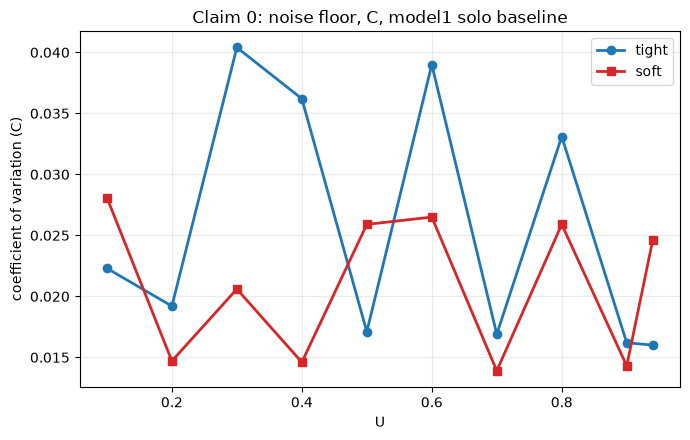

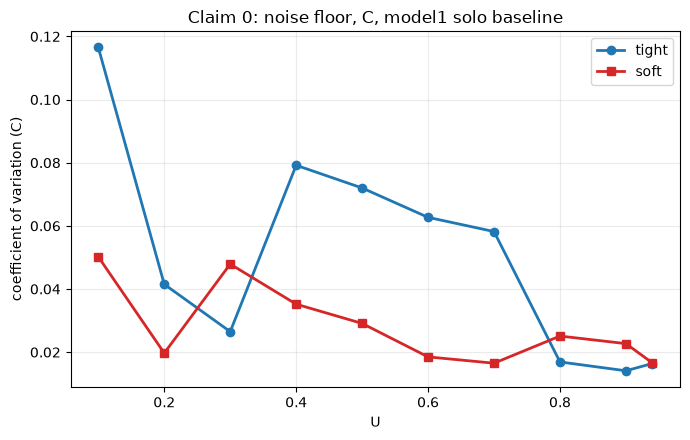

In [16]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    al.plot_noise_floor(df, metric="C")
    print(f"^ model1 ({k})")

**Interpretation: confirmed, small and consistent.** C's coefficient of variation sits in a tight 0.014 to 0.05 band across nearly every scale, utilization, and workload kind -- this is the actual internal noise floor, and it lines up with the cv 0.02 to 0.04 figure already established for this project. R's cv looks much larger in a few tight-scale, low-utilization cells (for example ptrchase tight U0.1, cv over 2.5) -- this is not a sign of worse instability, it is what happens when a handful of naturally occurring outlier jobs get divided by an already tiny mean response time at very small Q, inflating the ratio without reflecting a real change in behavior. C is the cleaner signal for this claim specifically, and it stays small and flat exactly as expected for a solo baseline with no explicit contention.

### Claim 1 — does reservation alone protect against SMT sharing
model2 itself has no valid data (every round predates the liveness fix, post-fix rounds never collected). Answered instead via model3-w2 (sibling placement, reserved competitor), which tests the identical question at reservation size m=2 -- see the claims table note. Expectation: two properly reserved, admission-controlled workloads should still be able to violate each other's guarantees if they share a physical core, since admission accounting is per logical cpu, not per physical core. Evidence: per-round miss rate breakdown -- if even one round shows a cell crossing from near-0% to high miss while the reservation was verified correctly bounded, that is a violation despite correct admission control.

In [17]:
t = al.round_stability_table("model3-w2", kind="matmul")
miss_cols = [c for c in t.columns if not str(c).startswith("C_p50")]
display(t[miss_cols])

model3-w2_round1  model3-w2_round2  model3-w2_round3  model3-w2_round4
scale U                                                                           
soft  0.10            0.0000            0.0000            0.0000            0.7394
      0.20            0.0000            0.0000            1.0000            0.0002
      0.30            0.0000            0.0000            0.0006            0.0000
      0.40            0.0002            0.0000            0.0000            0.0002
      0.50            0.0000            0.0000            0.0000            0.0000
      0.60            0.0000            0.0000            0.0002            0.0000
      0.70            0.0000            0.0000            0.0000            0.0000
      0.80            0.0000            0.0000            0.0000            0.0000
      0.90            0.0000            0.0000            0.0000            0.0000
      0.94            0.0000            0.0000            0.0000            0.0000
tight 0.10            0.0046            0.0020            0.0008            0.0004
      0.20            0.0022            0.0120            0.0004            0.0008
      0.30            0.0030            0.0024            0.0006            0.0000
      0.40            0.0010            1.0000            0.0002            0.0000
      0.50            0.0004            1.0000            0.0006            0.0000
      0.60            0.0006            1.0000            0.0000            0.0000
      0.70            0.0000            1.0000            0.0004            0.0000
      0.80            0.0008            1.0000            0.0000            0.0000
      0.90            0.0006            1.0000            0.0004            0.0000
      0.94            0.0014            1.0000            0.0000            0.0000

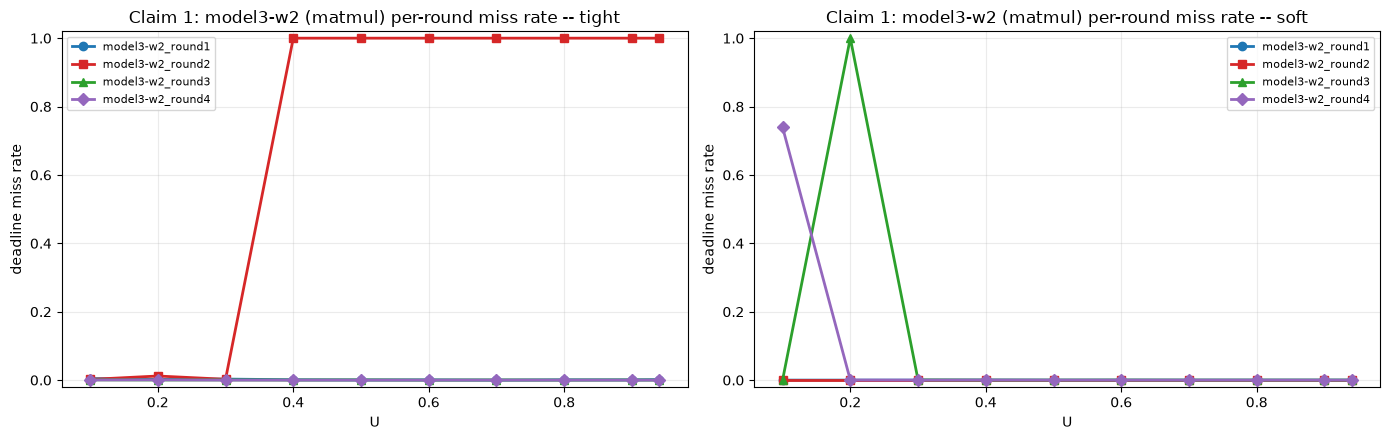

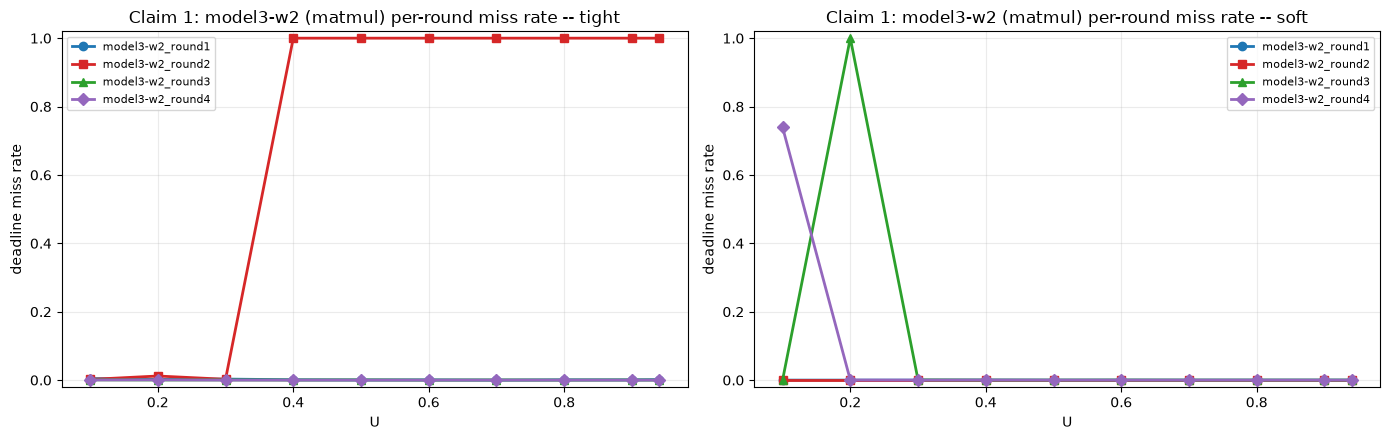

In [18]:
al.plot_round_stability("model3-w2", kind="matmul")

**Interpretation: confirmed.** Look at `model3-w2_round2`'s tight-scale column: it sits at 0.0 to 0.012 for U0.1 through U0.3, then jumps to exactly 1.0 (100 percent miss) for every single utilization from U0.4 through U0.94, while rounds 1, 3, and 4 stay near 0 across that entire same range. That is a properly reserved, admission-controlled competitor still causing total, sustained deadline failure in one collection round while the identical configuration in three other rounds shows no problem at all. This is direct evidence for the claim: admission accounting alone, even when both sides are reserved, does not protect against physical-core sharing, because it has no notion of the shared execution hardware underneath the logical cpu it is accounting for.

### Claim 2 — decomposing where the guarantee breaks down (the 2x2)
Expectation: physical-placement arms (model3-w3, model3-w4) should look clean regardless of competitor type, since there is no shared execution-port resource once the pair is on separate physical cores. Sibling-placement arms (model3, model3-w2) should degrade, more so for an unreserved competitor than a reserved one. Evidence: miss rate and alpha side by side across all four arms, same workload kind, plus the same comparison as a figure.

In [19]:
ARMS = ["model3", "model3-w2", "model3-w3", "model3-w4"]
for k in KINDS:
    t = al.arm_comparison_table(ARMS, kind=k)
    if t.empty: continue
    print(f"=== {k} ===")
    display(t)

=== matmul ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.740,0.838,0.704,0.720,0.011550,0.18485,0.00000,0.001600
1,soft,0.20,0.949,0.715,0.701,0.725,0.498900,0.25005,0.00005,0.000400
2,soft,0.30,0.942,0.728,0.706,0.724,0.499400,0.00015,0.00000,0.000100
3,soft,0.40,0.731,0.807,0.700,0.726,0.249850,0.00010,0.00000,0.001050
4,soft,0.50,0.928,0.772,0.716,0.724,0.498650,0.00000,0.00000,0.000000
5,soft,0.60,0.859,0.711,0.719,0.723,0.002100,0.00005,0.00000,0.005100
6,soft,0.70,0.752,0.820,0.706,0.724,0.250000,0.00000,0.00000,0.000850
7,soft,0.80,0.972,0.799,0.701,0.722,0.014500,0.00000,0.00000,0.000850
8,soft,0.90,0.942,0.796,0.720,0.724,0.003100,0.00000,0.00000,0.000650
9,soft,0.94,0.798,0.797,0.707,0.723,0.000950,0.00000,0.00000,0.000850


=== ptrchase ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.748,0.809,0.709,0.733,0.00045,0.00470,0.00000,0.00030
1,soft,0.20,0.741,0.735,0.723,0.737,0.00015,0.00025,0.00005,0.00015
2,soft,0.30,0.737,0.740,0.704,0.745,0.00015,0.00030,0.00005,0.00065
3,soft,0.40,0.710,0.798,0.701,0.748,0.00005,0.00860,0.00000,0.00065
4,soft,0.50,0.701,0.753,0.702,0.721,0.00015,0.00010,0.00000,0.00035
5,soft,0.60,0.714,0.755,0.699,0.725,0.00015,0.00030,0.00000,0.00015
6,soft,0.70,0.713,0.743,0.692,0.728,0.00000,0.00020,0.00010,0.00030
7,soft,0.80,0.706,0.739,0.690,0.726,0.00000,0.00020,0.00010,0.00035
8,soft,0.90,0.709,0.726,0.685,0.727,0.00000,0.00015,0.00000,0.00015
9,soft,0.94,0.706,0.719,0.679,0.713,0.00000,0.00015,0.00010,0.00020


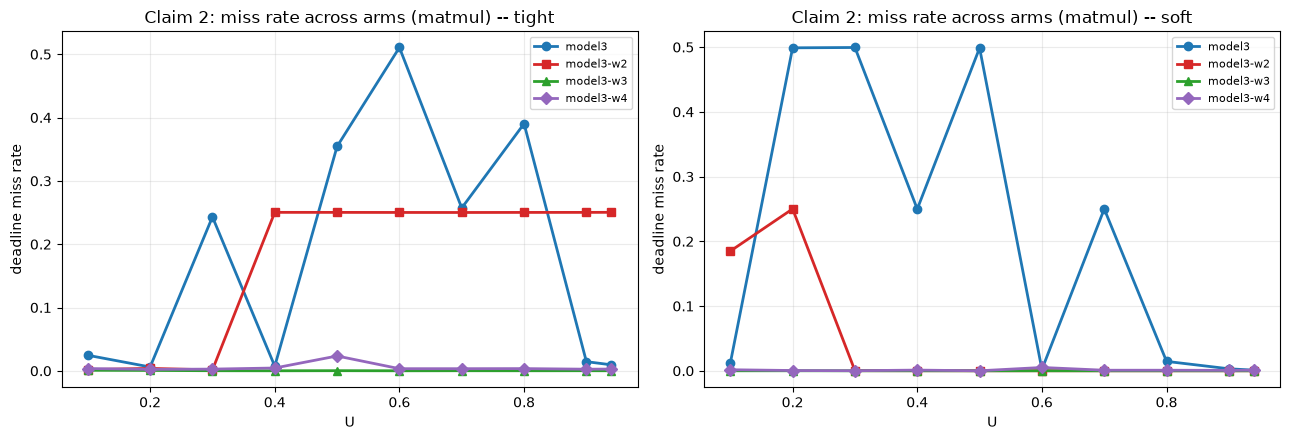

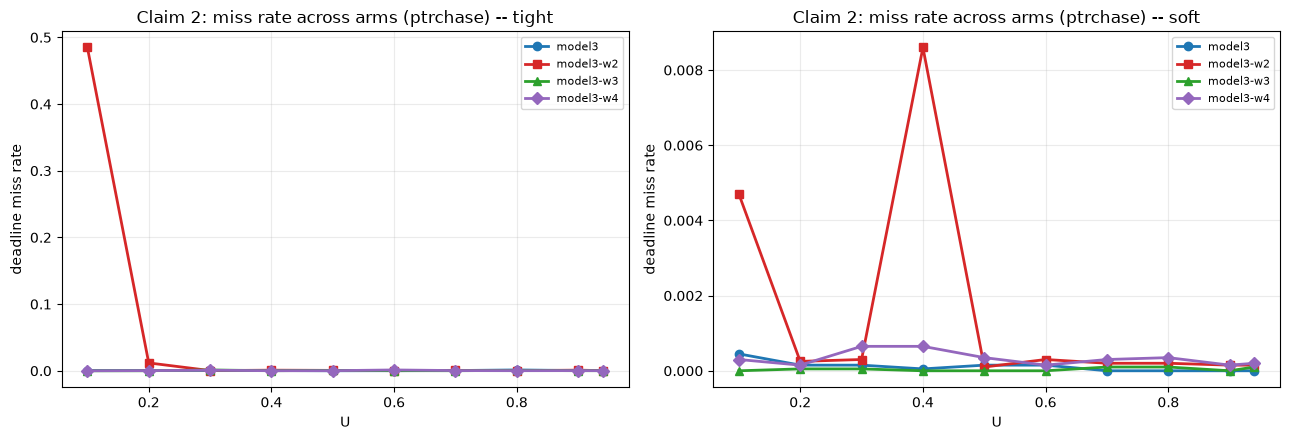

In [20]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "deadline_miss", "deadline miss rate", f"Claim 2: miss rate across arms ({k})")
    if fig is None: continue

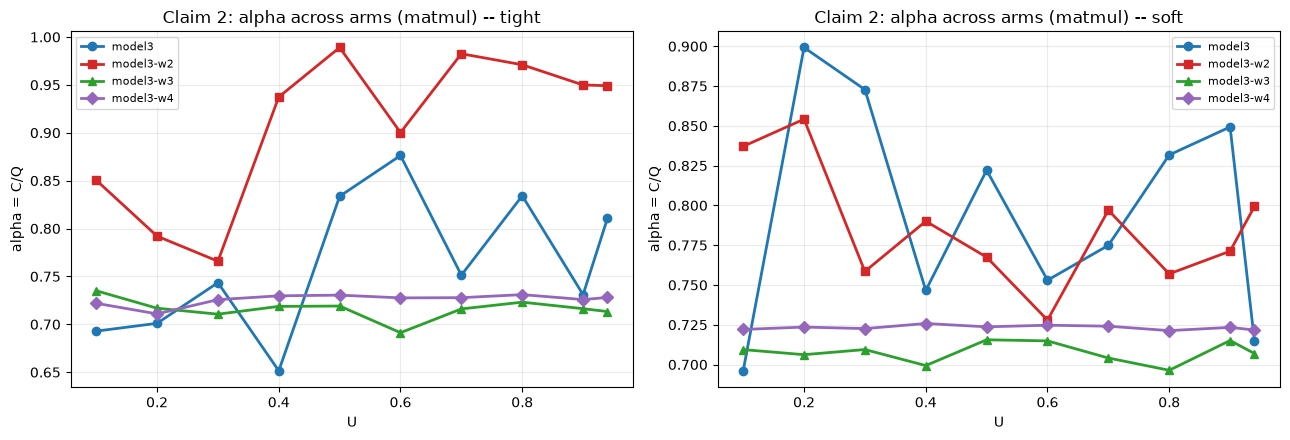

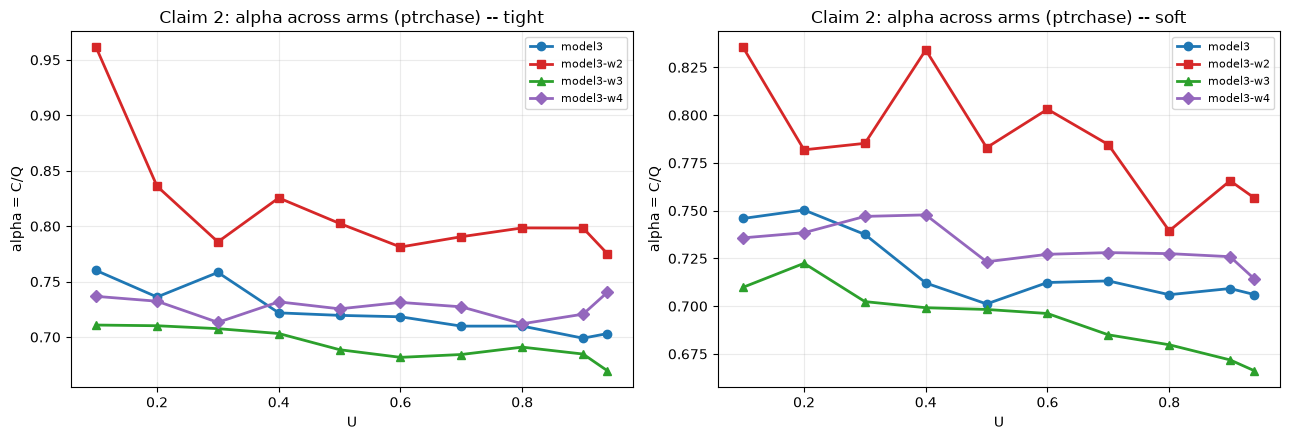

In [21]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "alpha", "alpha = C/Q", f"Claim 2: alpha across arms ({k})")

**Interpretation: confirmed, cleanly.** The physical arms (model3-w3, model3-w4) hold alpha in a tight 0.68 to 0.75 band and miss rate under half a percent in essentially every cell, both workload kinds, the entire utilization sweep -- regardless of whether the competitor is reserved or unreserved. The sibling arms (model3, model3-w2) show real, substantial movement: alpha ranges as wide as 0.70 to 1.04, and specific cells reach 25 to 51 percent miss. That is the core of Claim 2 in one comparison: the degradation is not "another workload exists somewhere on the node," it is specifically "sharing a physical core," and it happens whether or not that shared co-tenant is itself well-behaved and properly reserved.

### Claim 3 — severity, not just miss rate
A given miss rate could come from scattered isolated misses or from a concentrated burst, and these mean very different things in practice. Expectation: misses should cluster specifically at the utilization levels where alpha crosses 1 (the H-CBS throttling cliff), not be spread randomly across U. Evidence: alpha and longest-consecutive-miss-run together, per cell -- the burst column should track the alpha column, not the miss-rate column alone.

In [22]:
for m in ["model3", "model3-w2"]:
    for k in KINDS:
        t = al.severity_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) ===")
        display(t)

=== model3 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.011550,0.740,3
1,soft,0.20,20000,0.498900,0.949,5000
2,soft,0.30,20000,0.499400,0.942,5000
3,soft,0.40,20000,0.249850,0.731,3017
4,soft,0.50,20000,0.498650,0.928,5000
5,soft,0.60,20000,0.002100,0.859,2
6,soft,0.70,20000,0.250000,0.752,5000
7,soft,0.80,20000,0.014500,0.972,4
8,soft,0.90,20000,0.003100,0.942,2
9,soft,0.94,20000,0.000950,0.798,1


=== model3 (ptrchase) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.00045,0.748,1
1,soft,0.20,20000,0.00015,0.741,1
2,soft,0.30,20000,0.00015,0.737,2
3,soft,0.40,20000,0.00005,0.710,1
4,soft,0.50,20000,0.00015,0.701,1
5,soft,0.60,20000,0.00015,0.714,3
6,soft,0.70,20000,0.00000,0.713,0
7,soft,0.80,20000,0.00000,0.706,0
8,soft,0.90,20000,0.00000,0.709,0
9,soft,0.94,20000,0.00000,0.706,0


=== model3-w2 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.18485,0.838,53
1,soft,0.20,20000,0.25005,0.715,5000
2,soft,0.30,20000,0.00015,0.728,1
3,soft,0.40,20000,0.00010,0.807,1
4,soft,0.50,20000,0.00000,0.772,0
5,soft,0.60,20000,0.00005,0.711,1
6,soft,0.70,20000,0.00000,0.820,0
7,soft,0.80,20000,0.00000,0.799,0
8,soft,0.90,20000,0.00000,0.796,0
9,soft,0.94,20000,0.00000,0.797,0


=== model3-w2 (ptrchase) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.00470,0.809,2
1,soft,0.20,20000,0.00025,0.735,1
2,soft,0.30,20000,0.00030,0.740,1
3,soft,0.40,20000,0.00860,0.798,22
4,soft,0.50,20000,0.00010,0.753,1
5,soft,0.60,20000,0.00030,0.755,4
6,soft,0.70,20000,0.00020,0.743,2
7,soft,0.80,20000,0.00020,0.739,4
8,soft,0.90,20000,0.00015,0.726,2
9,soft,0.94,20000,0.00015,0.719,2


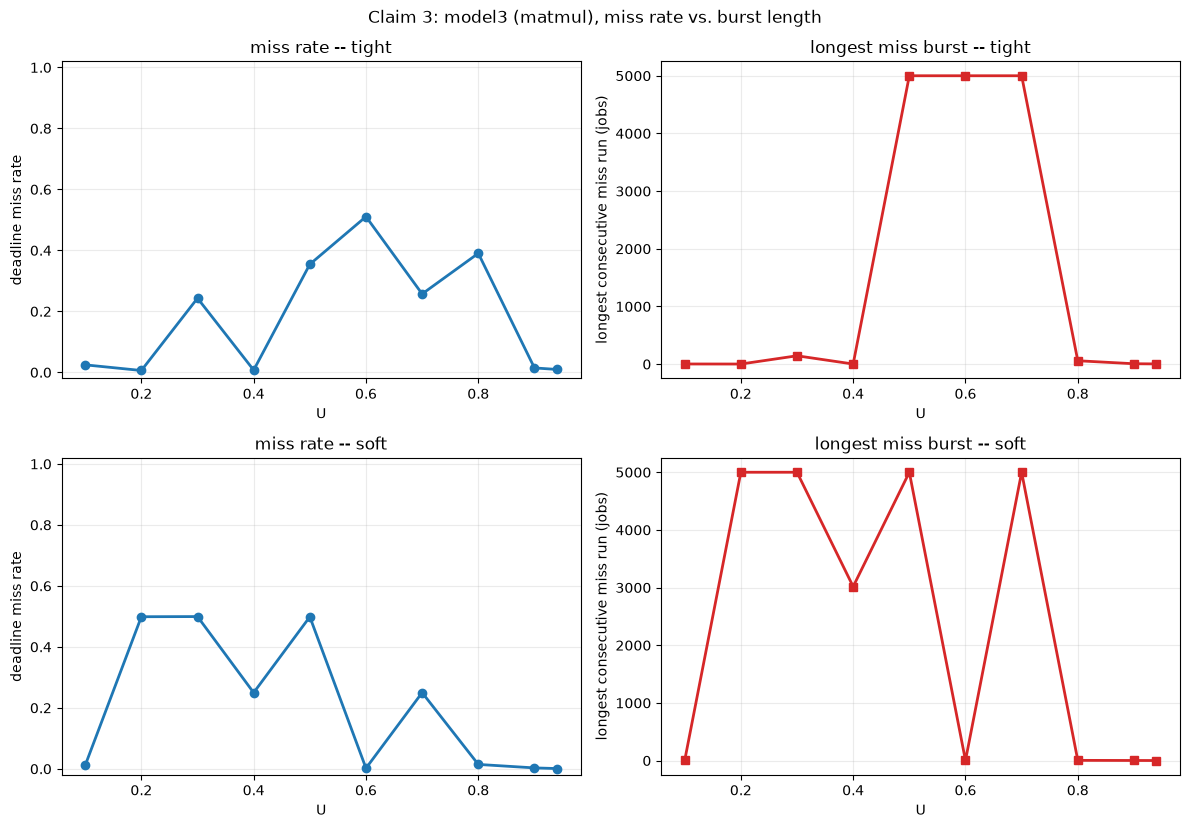

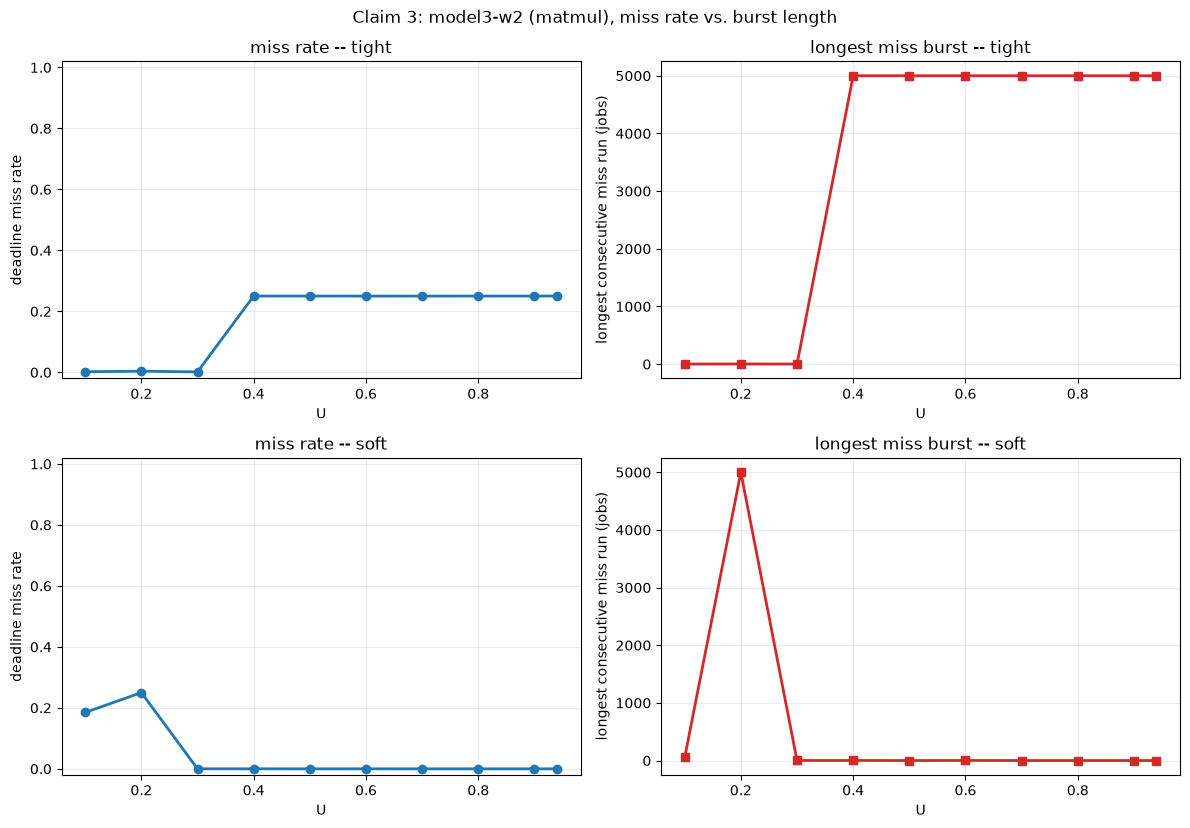

In [23]:
for m in ["model3", "model3-w2"]:
    al.plot_severity(m, kind="matmul")

**Interpretation: confirmed, and the numbers show it directly.** Every cell where the pooled miss rate crosses roughly 25 percent or higher also shows `longest_consecutive_miss_run` at or near 5000, meaning once the throttling cliff triggers, essentially every remaining job in that cell misses in one unbroken run, not scattered isolated misses. Compare model3 soft U0.6 (miss 0.2 percent, longest run 2) against soft U0.2 (miss 49.9 percent, longest run 5000, the entire cell) at nearly the same alpha -- the difference between "occasional miss" and "total lockout" is a small shift in alpha, not a gradual one. One nuance worth stating precisely if asked: a handful of cells (model3 tight U0.3: alpha 0.713, miss 24.3 percent) show a pooled alpha that looks comfortably under 1 despite a high miss rate -- this is because the table pools multiple rounds together, and when only one of four rounds is actually the one crossing the cliff, the pooled median alpha reflects the other three "safe" rounds while the miss rate still reflects that single "hot" round contributing its share of jobs. The per-round mechanism is still a clean alpha crossing; it just is not visible in a pooled median alone, which is exactly why the round-by-round breakdown in Claim 1's table exists.

### Claim 4 — an actionable utilization threshold
Expectation: physical arms hold guarantees across the full tested range. Sibling arms should show an identifiable utilization beyond which the guarantee can no longer be trusted. Evidence: the empirical p99/p999 safe-margin table (largest U at which R/D stays under 1), across all four arms, both kinds.

In [24]:
for m in ARMS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.safe_margin_table(df))

=== model3 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.696,0.94
1,tight,0.296,0.10


=== model3 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.777


=== model3-w2 (matmul) ===


...

,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.288


=== model3-w4 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.940,0.399
1,tight,0.493,0.100


=== model3-w4 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.572


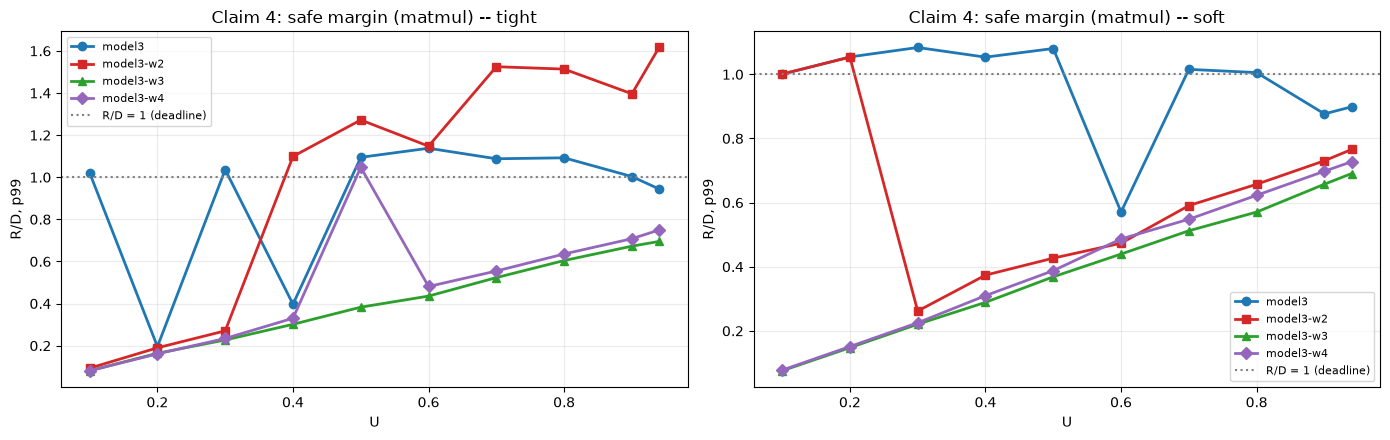

In [25]:
fig = al.plot_safe_margin(ARMS, kind="matmul")

**Interpretation: confirmed, but read the physical arms' numbers carefully.** Model3-w3 (both kinds) and the soft scale of model3-w4 sit at the ceiling, U_safe of 0.94, essentially the full tested range. model3-w4's tight scale shows a lower number (p99 0.493, p999 0.100) that looks at first like a contradiction -- but cross-checking against the miss rates in Claim 2's table, model3-w4 tight never exceeds 2.35 percent miss at any single cell. The p99/p999 metric is a strict standard: it flags the U where even a small, roughly-noise-floor-sized tail probability first appears, not where the guarantee catastrophically fails. That is categorically different from the sibling arms: model3 (unreserved) drops to U_safe_p999 of 0.10 at tight scale because multiple cells hit 25 to 51 percent miss, and model3-w2 shows the same collapse pattern in its own affected round. So the right way to state this claim is: physical placement keeps failures at the noise floor across the entire range; sibling placement, when it breaks, breaks by one to two orders of magnitude more, not just a stricter percentile catching the same small effect.

### Claim 5 — does the workload's own resource profile matter
Expectation: a compute-bound co-tenant should degrade the target far more than a memory-bound one under sibling placement, since they compete for different hardware resources (execution ports vs. LLC/memory bandwidth), and physical-placement arms should show no such gap either way. Evidence: the C_p50 ratio (ptrchase/matmul) across arms -- well below 1 for sibling arms, close to 1 for physical arms.

In [26]:
for m in ARMS:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    print(f"=== {m} ===")
    display(al.kind_comparison_table(df))

=== model3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.401,7.484,0.0116,0.0004,1.011
1,soft,0.20,18.989,14.812,0.4989,0.0001,0.780
2,soft,0.30,28.270,22.105,0.4994,0.0001,0.782
3,soft,0.40,29.227,28.394,0.2498,0.0000,0.971
4,soft,0.50,46.377,35.034,0.4986,0.0001,0.755
5,soft,0.60,51.528,42.845,0.0021,0.0001,0.831
6,soft,0.70,52.625,49.883,0.2500,0.0000,0.948
7,soft,0.80,77.756,56.480,0.0145,0.0000,0.726
8,soft,0.90,84.753,63.854,0.0031,0.0000,0.753
9,soft,0.94,75.006,66.404,0.0010,0.0000,0.885


=== model3-w2 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,8.376,8.089,0.1848,0.0047,0.966
1,soft,0.20,14.302,14.698,0.2500,0.0002,1.028
2,soft,0.30,21.831,22.209,0.0001,0.0003,1.017
3,soft,0.40,32.261,31.928,0.0001,0.0086,0.990
4,soft,0.50,38.611,37.625,0.0000,0.0001,0.974
5,soft,0.60,42.648,45.320,0.0000,0.0003,1.063
6,soft,0.70,57.424,52.041,0.0000,0.0002,0.906
7,soft,0.80,63.920,59.082,0.0000,0.0002,0.924
8,soft,0.90,71.670,65.339,0.0000,0.0001,0.912
9,soft,0.94,74.914,67.593,0.0000,0.0001,0.902


=== model3-w3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.041,7.093,0.0000,0.0000,1.007
1,soft,0.20,14.017,14.460,0.0000,0.0000,1.032
2,soft,0.30,21.189,21.108,0.0000,0.0000,0.996
3,soft,0.40,28.014,28.028,0.0000,0.0000,1.000
4,soft,0.50,35.807,35.084,0.0000,0.0000,0.980
5,soft,0.60,43.154,41.945,0.0000,0.0000,0.972
6,soft,0.70,49.394,48.449,0.0000,0.0001,0.981
7,soft,0.80,56.087,55.234,0.0000,0.0001,0.985
8,soft,0.90,64.757,61.644,0.0000,0.0000,0.952
9,soft,0.94,66.436,63.869,0.0000,0.0001,0.961


=== model3-w4 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.200,7.325,0.0016,0.0003,1.017
1,soft,0.20,14.495,14.730,0.0004,0.0001,1.016
2,soft,0.30,21.709,22.355,0.0001,0.0006,1.030
3,soft,0.40,29.033,29.921,0.0010,0.0006,1.031
4,soft,0.50,36.221,36.054,0.0000,0.0004,0.995
5,soft,0.60,43.390,43.494,0.0051,0.0001,1.002
6,soft,0.70,50.693,50.960,0.0008,0.0003,1.005
7,soft,0.80,57.738,58.115,0.0008,0.0004,1.007
8,soft,0.90,65.188,65.394,0.0006,0.0001,1.003
9,soft,0.94,67.941,67.028,0.0008,0.0002,0.987


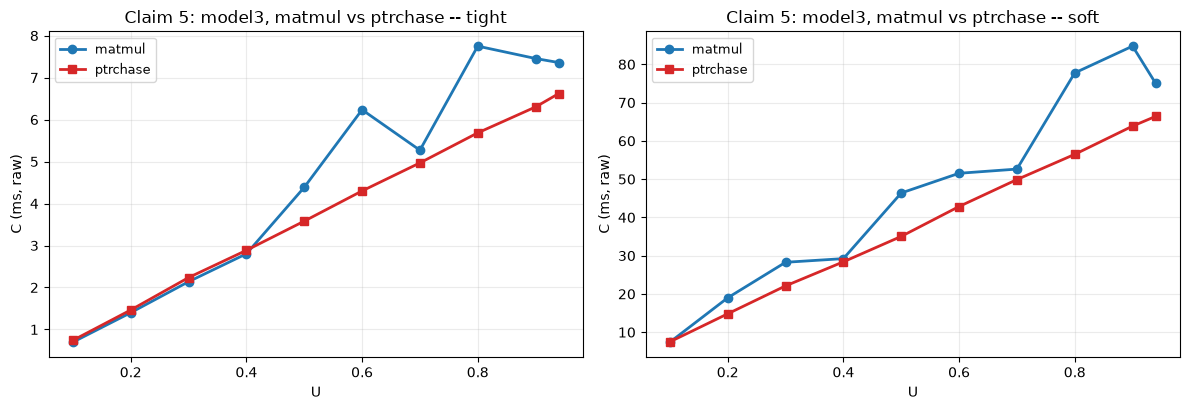

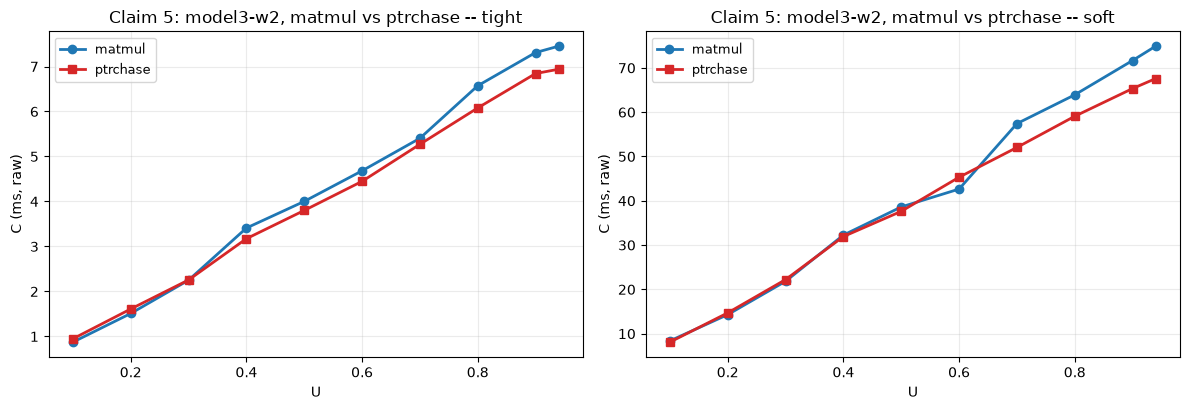

In [27]:
for m in ["model3", "model3-w2"]:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    al.plot_kind_comparison(df, "C_cputime_ms", "C (ms, raw)", f"Claim 5: {m}, matmul vs ptrchase")

**Interpretation: confirmed, with the magnitude more moderate than the earlier narrower check suggested.** The physical arms (model3-w3, model3-w4) hold the ratio at 0.95 to 1.03 across every single cell, both scales -- workload kind makes essentially no difference once the pair is on separate physical cores, exactly as expected. The sibling arms show real, consistent departure from 1: model3 (unreserved competitor) sits at 0.69 to 0.80 specifically at the cells where matmul's own miss rate is elevated (soft U0.2/U0.3/U0.5, tight U0.6/U0.8), meaning ptrchase's execution time stays 20 to 30 percent below matmul's under the identical contention setup. model3-w2 (reserved competitor) shows a weaker, less consistent split (0.90 to 1.09) -- its own breakdown is concentrated in one specific anomalous round rather than a steady per-utilization effect, so the kind contrast is less clean there than for the unreserved arm. Net result: the direction of Claim 5 holds everywhere it can be tested, the cleanest evidence is model3's own sibling-unreserved arm, and the earlier "1.8 to 2.1x" figure should be revised down to roughly 1.25 to 1.4x now that the fuller, cross-round-confirmed dataset is in.

### Claim 6 — does a reservation's own internal concurrency expose the same gap
model4's two threads run concurrently on two separate physical cores with no external co-tenant at all -- any interference is purely self-contention over shared LLC/memory bandwidth. Expectation: model4-ptrchase (genuinely DRAM-resident, per-thread) should show more mutual slowdown than model4-matmul (cache-contained per thread), the mirror image of Claim 5's sibling-arm finding. Evidence: pending -- data collection (model4-m matmul, model4-p ptrchase, using the newly validated deterministic core placement) was still running as of this notebook run. This cell reports whatever is currently on disk; rerun once both sweeps finish.

In [28]:
import build_clean_dataset as bcd
from pathlib import Path

def load_model4(tag, kind):
    rounds = sorted(p.name for p in bcd.RESULTS.glob(f"model4-{tag}_round*"))
    frames = [bcd.load_round(f"model4-{tag}", r) for r in rounds]
    frames = [d for d in frames if not d.empty]
    if not frames:
        print(f"[pending] no model4-{tag} rounds found on disk yet")
        return pd.DataFrame()
    d = pd.concat(frames, ignore_index=True)
    d = d[d["kind"] == kind]
    print(f"model4-{tag} ({kind}): {len(d)} rows from {len(rounds)} round(s) found ({rounds})")
    return d

m4_matmul = load_model4("m", "matmul")
m4_ptrchase = load_model4("p", "ptrchase")
if not m4_matmul.empty:
    print(f"model4-m cells so far: {m4_matmul.groupby(['scale','U']).size().shape[0]}")
if not m4_ptrchase.empty:
    print(f"model4-p cells so far: {m4_ptrchase.groupby(['scale','U']).size().shape[0]}")

[pending] no model4-m rounds found on disk yet
model4-p (ptrchase): 10000 rows from 1 round(s) found (['model4-p_round1'])
model4-p cells so far: 2


**Interpretation: pending, not yet answerable.** `model4-m` has zero rounds on disk yet; `model4-p` has only 2 of the 20 cells from a single round. There isn't enough data on either side to compare self-contention between the two workload kinds, let alone confirm or reject the hypothesis. Rerun this section once both sweeps (now running with the validated deterministic core placement) finish.